# Extracció de Pesos CAV i Interpretabilitat Basada en Conceptes sobre TNet

---

## 1. Introducció i Motivació

### 1.1 Context: Interpretabilitat en Xarxes Neuronals Profundes

Les xarxes neuronals convolucionals (CNN) han demostrat un rendiment excepcional en tasques de classificació d'imatges, però el seu funcionament intern roman opac — un problema conegut com la **caixa negra** (*black box*). Comprendre *per què* un model pren una decisió concreta és essencial tant per a la validació científica com per a l'aplicació en entorns reals.

Els mètodes clàssics d'atribució de característiques (p. ex., **saliency maps**, **Grad-CAM**) operen a nivell de píxel, generant mapes de calor que indiquen quines regions de la imatge influeixen la predicció. Tot i ser útils, aquests mètodes no responen directament a la pregunta:

> *El model ha après a reconèixer conceptes d'alt nivell com "cercle", "quadrat" o "creu"? I si és així, a quines capes internes es codifiquen?*

### 1.2 TCAV: Testing with Concept Activation Vectors

**TCAV** (Kim et al., 2018) proporciona una metodologia per respondre aquesta pregunta. La idea central és:

1. Definir **conceptes** mitjançant conjunts d'imatges representatives (p. ex., imatges que contenen cercles).
2. Per a cada capa interna $\ell$ del model, recollir les **activacions intermèdies** quan es processen imatges del concepte i imatges aleatòries (control).
3. Entrenar un **classificador lineal** (regressió logística) per separar les activacions del concepte de les aleatòries. El vector de pesos d'aquest classificador defineix el **Vector d'Activació del Concepte (CAV)**:

$$\mathbf{v}_c^\ell \in \mathbb{R}^D$$

on $D$ és la dimensionalitat de l'espai d'activacions a la capa $\ell$.

4. Calcular la **derivada direccional** de la sortida del model en la direcció del CAV per quantificar quant influeix el concepte en la predicció.

### 1.3 Objectius d'aquest Notebook

Aquest notebook implementa un pipeline complet d'interpretabilitat basada en conceptes sobre un model personalitzat (**TNet**), amb tres contribucions principals:

1. **Extracció explícita dels pesos CAV** per a cada parell concepte-capa, amb anàlisi estadística de les magnituds.
2. **Projecció espacial dels pesos CAV** sobre mapes d'activació per generar **mapes de calor de localització de conceptes** — un mètode que no depèn del gradient de la sortida.
3. **Diagnòstic d'un mode de fallada** de TCAV sota **saturació de la sigmoide**, i demostració que la projecció CAV el circumventa.

### 1.4 Referències

- Kim, B. et al. (2018). *Interpretability Beyond Feature Attribution: Quantitative Testing with Concept Activation Vectors (TCAV)*. ICML 2018.
- Kokhlikyan, N. et al. (2020). *Captum: A unified and generic model interpretability library for PyTorch*.

---

## 2. Configuració de l'Entorn i Importacions

**Raonament:** Abans de qualsevol experimentació, cal establir un entorn reproduïble. Fixem el directori de treball al directori arrel del projecte per garantir que tots els camins relatius (dades, pesos, model) siguin consistents independentment d'on s'executi el notebook.

**Dependències clau:**
- **PyTorch**: Inferència del model i operacions tensorials.
- **Captum** (`captum.concept`): Implementació de TCAV, incloent `TCAV`, `Concept`, `CustomIterableDataset`.
- **NumPy / Matplotlib / PIL**: Càlcul numèric, visualització i entrada/sortida d'imatges.

In [1]:
import sys, os
os.chdir("/Users/dylancanning/Documents/TFG/Tcav_Captum/Testing-with-Concept-Activation-Vectors")

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from captum.concept import TCAV, Concept
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset

from model.model_sq import TNet

print("Importacions completades correctament.")
print(f"Directori de treball: {os.getcwd()}")

Importacions completades correctament.
Directori de treball: /Users/dylancanning/Documents/TFG/Tcav_Captum/Testing-with-Concept-Activation-Vectors


/opt/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 3. Model Objectiu: Arquitectura TNet

### 3.1 Descripció de l'Arquitectura

**TNet** és una xarxa neuronal convolucional personalitzada de 5 blocs convolucionals seguida de 3 capes fully connected, dissenyada per a **classificació binària** sobre imatges en escala de grisos de $128 \times 128$ píxels.

L'arquitectura segueix un patró piramidal típic on el nombre de canals augmenta progressivament mentre les dimensions espacials es redueixen per un factor de 2 a cada bloc (via `MaxPool2d`):

| Bloc | Capes | Forma de Sortida |
|------|-------|------------------|
| Conv 1 | `Conv2d(1, 25, 3×3, same)` → `ReLU` → `MaxPool2d(2×2)` | $[25, 64, 64]$ |
| Conv 2 | `Conv2d(25, 35, 3×3, same)` → `ReLU` → `MaxPool2d(2×2)` | $[35, 32, 32]$ |
| Conv 3 | `Conv2d(35, 50, 3×3, same)` → `ReLU` → `BatchNorm2d` → `MaxPool2d(2×2)` | $[50, 16, 16]$ |
| Conv 4 | `Conv2d(50, 75, 3×3, same)` → `ReLU` → `BatchNorm2d` → `MaxPool2d(2×2)` | $[75, 8, 8]$ |
| Conv 5 | `Conv2d(75, 125, 3×3, same)` → `ReLU` → `BatchNorm2d` → `MaxPool2d(2×2)` | $[125, 4, 4]$ |
| Flatten | — | $[2000]$ |
| FC 1 | `Linear(2000, 500)` → `Dropout(0.2)` → `ReLU` | $[500]$ |
| FC 2 | `Linear(500, 250)` → `Dropout(0.2)` → `ReLU` | $[250]$ |
| FC 3 | `Linear(250, 50)` → `Dropout(0.2)` → `ReLU` | $[50]$ |
| Sortida | `Linear(50, 1)` → `Sigmoid` | $[1]$ |

### 3.2 Funció de la Sigmoide a la Sortida

El model utilitza una funció **sigmoide** a la capa de sortida:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

que mapa el logit $z \in \mathbb{R}$ a l'interval $(0, 1)$. La interpretació de la predicció és:

- $\hat{y} \approx 1.0$: La imatge **conté cercles** (classe "cercle present").
- $\hat{y} \approx 0.0$: La imatge és **dominant en quadrats sense cercles** (etiqueta $= 0$ si i només si `cercles == 0 AND quadrats > 0 AND quadrats >= creus`).

**Nota important per a TCAV:** La derivada de la sigmoide és $\sigma'(z) = \sigma(z)(1 - \sigma(z))$, que tendeix a zero quan $|z|$ és gran. Això tindrà conseqüències directes sobre les puntuacions TCAV, com veurem a la Secció 8.

### 3.3 Càrrega del Model

**Raonament:** Carreguem els pesos pre-entrenats des del fitxer `weights/only_sq.pt`. Inferim automàticament els paràmetres de l'arquitectura (nombre de canals d'entrada i classes) directament de les formes dels tensors del checkpoint, evitant així inconsistències entre arquitectura i pesos.

El model es posa en mode d'avaluació (`model.eval()`), que:
- Desactiva el **Dropout** (totes les neurones actives).
- Fa servir les estadístiques acumulades (*running mean/var*) del **BatchNorm** en comptes de les estadístiques del batch actual.

In [2]:
# =============================================
# Càrrega del model TNet pre-entrenat
# =============================================
PESOS = "weights/only_sq.pt"
DEVICE = torch.device("cpu")

obj = torch.load(PESOS, map_location=DEVICE, weights_only=True)
in_channels = obj["conv1.weight"].shape[1]
num_classes = obj["fc4.weight"].shape[0]

model = TNet(numChannels=in_channels, classes=num_classes, size_img=128)
model.to(DEVICE).eval()
model.load_state_dict(obj)

print(f"Model carregat: TNet(in_channels={in_channels}, classes={num_classes}) a {DEVICE}")
print(model)

Model carregat: TNet(in_channels=1, classes=1) a cpu
TNet(
  (conv1): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (bn1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(25, 35, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (bn2): BatchNorm2d(35, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(35, 50, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu3): ReLU()
  (bn3): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu4): ReLU()
  (bn4

---

## 4. Preprocessament d'Imatges i Construcció de Conceptes

### 4.1 Pipeline de Transformació

**Raonament:** Cada imatge d'entrada ha de passar per una seqüència de transformacions per adaptar-la al format que espera TNet:

1. **`Grayscale()`** — Converteix la imatge a un sol canal (escala de grisos). TNet espera `in_channels=1`.
2. **`Resize((128, 128))`** — Redimensiona a la resolució de l'arquitectura.
3. **`ToTensor()`** — Converteix la imatge PIL a un tensor `float32` normalitzat a $[0, 1]$.

Formalment, per a una imatge d'entrada $\mathbf{I} \in \{0, \ldots, 255\}^{H \times W}$, la transformació produeix:

$$\mathbf{X} = \frac{\text{Resize}(\text{Grayscale}(\mathbf{I}))}{255} \in [0, 1]^{1 \times 128 \times 128}$$

### 4.2 Funció de Construcció de Conceptes

**Raonament:** La biblioteca Captum requereix que cada concepte es representi com un objecte `Concept` amb un iterador de dades. Definim una funció fàbrica `assemble_concept` que:

1. Construeix el camí al directori del concepte (p. ex., `data/concepts/circle_full/`).
2. Crea un `CustomIterableDataset` que carrega les imatges de forma *lazy* (sota demanda).
3. L'embolcalla en un `DataLoader` mitjançant `dataset_to_dataloader`.
4. Retorna un objecte `Concept` amb un ID únic, un nom i l'iterador de dades.

Aquesta abstracció permet tractar de forma uniforme tant els conceptes geomètrics com els pools aleatoris de control.

In [3]:
# =============================================
# Pipeline de transformació i fàbrica de conceptes
# =============================================
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("L")
    return transform(img).to(DEVICE).float()

def assemble_concept(name, id, concepts_path="data/concepts"):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)
    return Concept(id=id, name=name, data_iter=concept_iter)

print("Pipeline de preprocessament i fàbrica de conceptes configurades.")

Pipeline de preprocessament i fàbrica de conceptes configurades.


---

## 5. Assemblatge dels Conceptes Experimentals

### 5.1 Conceptes Geomètrics

**Raonament:** Definim tres conceptes d'alt nivell corresponents a les formes geomètriques presents al dataset AIXI:

| Concepte | ID | Descripció | Directori |
|----------|----|------------|----------|
| `circle_full` | 0 | Imatges que contenen cercles | `data/concepts/circle_full/` |
| `cross_full` | 1 | Imatges que contenen creus | `data/concepts/cross_full/` |
| `square_full` | 2 | Imatges que contenen quadrats | `data/concepts/square_full/` |

### 5.2 Pools Aleatoris (Control)

En la metodologia TCAV, els pools aleatoris serveixen com a **classe negativa** quan s'entrena el classificador lineal (CAV). La seva funció és proporcionar una línia base estadísticament neutra:

> Si la direcció CAV d'un concepte no és més informativa que una direcció que separa imatges aleatòries, llavors el concepte **no està codificat de manera significativa** a aquella capa.

| Pool | ID | Propòsit |
|------|----|----------|
| `random_pool` | 100 | Línia base aleatòria principal |
| `random_pool_2` | 101 | Pool addicional (disponible però no utilitzat) |
| `random_pool_3` | 102 | Pool addicional |
| `random_pool_4` | 103 | Pool addicional |

In [4]:
# =============================================
# Assemblatge dels conceptes geomètrics i pools aleatoris
# =============================================
concepts_path = "./data/concepts"

# Conceptes de forma
circle_full = assemble_concept("circle_full", 0, concepts_path=concepts_path)
cross_full  = assemble_concept("cross_full",  1, concepts_path=concepts_path)
square_full = assemble_concept("square_full", 2, concepts_path=concepts_path)

# Pools aleatoris (control)
random_pool   = assemble_concept("random_pool",   100, concepts_path=concepts_path)
random_pool_2 = assemble_concept("random_pool_2", 101, concepts_path=concepts_path)
random_pool_3 = assemble_concept("random_pool_3", 102, concepts_path=concepts_path)
random_pool_4 = assemble_concept("random_pool_4", 103, concepts_path=concepts_path)

CONCEPTS = {
    "circle_full": circle_full,
    "cross_full":  cross_full,
    "square_full": square_full,
}

print(f"Conceptes assemblats: {list(CONCEPTS.keys())}")
print(f"Pools aleatoris: random_pool, random_pool_2, random_pool_3, random_pool_4")

Conceptes assemblats: ['circle_full', 'cross_full', 'square_full']
Pools aleatoris: random_pool, random_pool_2, random_pool_3, random_pool_4


---

## 6. Fonaments Teòrics dels Vectors d'Activació de Conceptes (CAV)

### 6.1 Intuïció Geomètrica

Considerem una capa interna $\ell$ d'una xarxa neuronal. Quan una imatge $\mathbf{X}$ passa per la xarxa, la capa $\ell$ produeix un tensor d'activacions $\mathbf{A}^\ell(\mathbf{X})$. Per a una capa convolucional amb $C$ canals i dimensions espacials $H \times W$:

$$\mathbf{A}^\ell(\mathbf{X}) \in \mathbb{R}^{C \times H \times W}$$

Per treballar amb classificadors lineals, aplanem (*flatten*) aquest tensor a un vector:

$$\mathbf{a}^\ell(\mathbf{X}) = \text{flatten}(\mathbf{A}^\ell(\mathbf{X})) \in \mathbb{R}^D, \quad D = C \cdot H \cdot W$$

### 6.2 Entrenament del Classificador Lineal

Sigui $\mathcal{P}_c = \{\mathbf{X}_1^c, \ldots, \mathbf{X}_n^c\}$ el conjunt d'imatges del concepte $c$ i $\mathcal{P}_r = \{\mathbf{X}_1^r, \ldots, \mathbf{X}_m^r\}$ el pool aleatori. Construïm un dataset d'entrenament:

$$\mathcal{D} = \{(\mathbf{a}^\ell(\mathbf{X}_i^c), 1)\}_{i=1}^n \cup \{(\mathbf{a}^\ell(\mathbf{X}_j^r), 0)\}_{j=1}^m$$

i entrenem un classificador de **regressió logística** que aprèn una matriu de pesos $\mathbf{W} \in \mathbb{R}^{2 \times D}$:

$$P(y = 1 \mid \mathbf{a}) = \sigma(\mathbf{w}_1^\top \mathbf{a} + b_1)$$

on $\mathbf{w}_1$ és la primera fila de $\mathbf{W}$ (pesos per a la classe "concepte"). Aquesta fila defineix el **CAV**:

$$\boxed{\mathbf{v}_c^\ell = \mathbf{w}_1 \in \mathbb{R}^D}$$

El CAV és la **direcció en l'espai d'activacions** que separa maximalment les activacions del concepte de les aleatòries.

### 6.3 Selecció de Capes i Conjunts Experimentals

**Raonament sobre la selecció de capes:** Sondem les capes `conv3` a `fc3`, excloent `conv1` i `conv2`. La justificació és:

- **Capes primerenques** (`conv1`, `conv2`): Codifiquen característiques de baix nivell (vores, textures) que són compartides entre conceptes i, per tant, poc discriminatives.
- **Capes convolucionals mitjanes-tardanes** (`conv3`, `conv4`, `conv5`): Preserven estructura espacial i codifiquen patrons de nivell superior (fragments de formes).
- **Capes fully connected** (`fc1`, `fc2`, `fc3`): L'estructura espacial s'ha col·lapsat, però la informació s'ha comprimit en representacions compactes i potencialment més específiques del concepte.

**Conjunts experimentals:** Cada concepte es compara amb el pool aleatori principal:

$$\text{circle\_full vs random\_pool}, \quad \text{cross\_full vs random\_pool}, \quad \text{square\_full vs random\_pool}$$

In [5]:
# =============================================
# Definició de capes a sondar i conjunts experimentals
# =============================================
LAYERS = ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']

experimental_sets = [
    [circle_full, random_pool],
    [cross_full,  random_pool],
    [square_full, random_pool],
]

print(f"Capes sondades: {LAYERS}")
print(f"Conjunts experimentals ({len(experimental_sets)}):")
for es in experimental_sets:
    print(f"  {es[0].name} vs {es[1].name}")

Capes sondades: ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']
Conjunts experimentals (3):
  circle_full vs random_pool
  cross_full vs random_pool
  square_full vs random_pool


---

## 7. Càlcul dels Vectors d'Activació de Conceptes (CAV)

### 7.1 Procés de Càlcul

**Raonament:** Per a cada triple (concepte $c$, pool aleatori $r$, capa $\ell$), l'algorisme:

1. Passa totes les imatges de $\mathcal{P}_c$ i $\mathcal{P}_r$ pel model.
2. Captura les activacions a la capa $\ell$.
3. Aplana les activacions a vectors 1D.
4. Entrena un classificador lineal (regressió logística via `DefaultClassifier` de Captum).
5. Emmagatzema la matriu de pesos $\mathbf{W} \in \mathbb{R}^{2 \times D}$ i les estadístiques de precisió.

**Estructura del resultat:** Un diccionari aniuat indexat per `"concept_id-random_id"` (p. ex., `"0-100"` per circle_full vs random_pool), després per nom de capa, contenint objectes `CAV` amb `.stats['weights']` i `.stats['accs']`.

**Nota tècnica:** El `DefaultClassifier` de Captum manté totes les dades d'entrenament en memòria, la qual cosa genera un avís. Per a experiments a gran escala, caldria implementar una subclasse de `Classifier` amb entrenament per lots (*batched training*).

In [6]:
# =============================================
# Càlcul dels CAVs
# =============================================
mytcav = TCAV(model=model, layers=LAYERS)

print("Calculant CAVs (3 conjunts × 6 capes)...")
cav_results = mytcav.compute_cavs(experimental_sets=experimental_sets)

print(f"\nClaus dels resultats CAV: {list(cav_results.keys())}")
for key in cav_results:
    layers_available = list(cav_results[key].keys())
    print(f"  '{key}' -> capes: {layers_available}")

Calculant CAVs (3 conjunts × 6 capes)...

Claus dels resultats CAV: ['0-100', '1-100', '2-100']
  '0-100' -> capes: ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']
  '1-100' -> capes: ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']
  '2-100' -> capes: ['conv3', 'conv4', 'conv5', 'fc1', 'fc2', 'fc3']


/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


---

## 8. Extracció i Anàlisi dels Pesos CAV

### 8.1 Estructura de la Matriu de Pesos

Per a cada parell (concepte, capa), el classificador lineal ha après una matriu $\mathbf{W} \in \mathbb{R}^{2 \times D}$:

- **Fila 0** ($\mathbf{w}_0$): Pesos per a la **classe concepte** (direcció positiva). Aquesta fila **és el CAV**.
- **Fila 1** ($\mathbf{w}_1$): Pesos per a la **classe aleatòria** (direcció negativa).

Extraiem únicament la Fila 0, ja que defineix la direcció en l'espai d'activacions al llarg de la qual el concepte està maximalment activat respecte a l'aleatorietat.

### 8.2 Interpretació de les Dimensions

La dimensionalitat $D$ del vector CAV varia segons la capa:

| Capa | $D$ | Descomposició | Naturalesa |
|------|-----|---------------|------------|
| `conv3` | 51.200 | $50 \times 32 \times 32$ | Característiques espacials d'alta dimensió |
| `conv4` | 19.200 | $75 \times 16 \times 16$ | Codificació espacial/canal intermèdia |
| `conv5` | 8.000 | $125 \times 8 \times 8$ | Característiques convolucionals tardanes |
| `fc1` | 500 | — | Primera capa fully connected |
| `fc2` | 250 | — | Segona capa fully connected |
| `fc3` | 50 | — | Capa pre-sortida |

**Raonament sobre les magnituds esperades:** A mesura que la dimensionalitat disminueix (capes més profundes), esperem que els pesos individuals augmentin en magnitud, ja que menys dimensions han de capturar la mateixa informació discriminativa — la informació es "concentra" en menys dimensions.

In [7]:
# =============================================
# Extracció dels pesos CAV per a cada concepte × capa
# =============================================
key_to_concept = {
    '0-100': 'circle_full',
    '1-100': 'cross_full',
    '2-100': 'square_full',
}

cav_weights = {}  # {concept_name: {layer: numpy_array}}

for cav_key, concept_name in key_to_concept.items():
    cav_data = cav_results[cav_key]
    cav_weights[concept_name] = {}
    
    for layer_name in LAYERS:
        cav_obj = cav_data[layer_name]
        raw_weights = cav_obj.stats['weights']
        
        if torch.is_tensor(raw_weights):
            w = raw_weights.detach().cpu().numpy()
        else:
            w = np.array(raw_weights)
        
        # Fila 0 = classe concepte (el CAV), Fila 1 = classe aleatòria
        w_concept = w[0]
        cav_weights[concept_name][layer_name] = w_concept
    
    print(f"\n{concept_name}:")
    for layer_name, w in cav_weights[concept_name].items():
        print(f"  {layer_name}: forma={w.shape}, max|w|={np.abs(w).max():.4f}, "
              f"mitjana|w|={np.abs(w).mean():.6f}, norma L2={np.linalg.norm(w):.4f}")


circle_full:
  conv3: forma=(51200,), max|w|=0.0086, mitjana|w|=0.002269, norma L2=0.6480
  conv4: forma=(19200,), max|w|=0.0209, mitjana|w|=0.002961, norma L2=0.5303
  conv5: forma=(8000,), max|w|=0.2637, mitjana|w|=0.041655, norma L2=4.8679
  fc1: forma=(500,), max|w|=0.6305, mitjana|w|=0.152752, norma L2=4.2360
  fc2: forma=(250,), max|w|=1.5804, mitjana|w|=0.460150, norma L2=8.9401
  fc3: forma=(50,), max|w|=1.4281, mitjana|w|=0.409964, norma L2=3.7896

cross_full:
  conv3: forma=(51200,), max|w|=0.0067, mitjana|w|=0.001946, norma L2=0.5477
  conv4: forma=(19200,), max|w|=0.0232, mitjana|w|=0.002710, norma L2=0.4862
  conv5: forma=(8000,), max|w|=0.2029, mitjana|w|=0.028881, norma L2=3.6227
  fc1: forma=(500,), max|w|=1.2949, mitjana|w|=0.518104, norma L2=13.2791
  fc2: forma=(250,), max|w|=1.3683, mitjana|w|=0.574633, norma L2=10.1945
  fc3: forma=(50,), max|w|=0.0448, mitjana|w|=0.018231, norma L2=0.1554

square_full:
  conv3: forma=(51200,), max|w|=0.0082, mitjana|w|=0.002331, 

---

## 9. Visualització dels Top-$N$ Pesos CAV

### 9.1 Metodologia

**Raonament:** Per entendre quines dimensions de l'espai d'activacions són més discriminatives per a cada concepte, ordenem els pesos CAV per valor absolut descendent i visualitzem els $N = 20$ de major magnitud.

Per a cada parell (concepte $c$, capa $\ell$):

1. Ordenem els pesos: $\pi = \text{argsort}(|\mathbf{v}_c^\ell|)$ en ordre descendent.
2. Seleccionem els top-$N$: $\{v_{\pi(1)}, v_{\pi(2)}, \ldots, v_{\pi(N)}\}$.
3. Representem amb barres **blaves** (pesos positius: la característica suporta presència del concepte) i **vermelles** (pesos negatius: la característica suporta absència del concepte).

### 9.2 Interpretació

- **Pocs pesos dominants** → codificació **dispersa** (*sparse*): el concepte es concentra en poques dimensions.
- **Distribució uniforme** → codificació **distribuïda**: moltes dimensions contribueixen de forma similar.
- Per a capes convolucionals, els índexs es poden mapar a posicions $(\text{canal}, \text{fila}, \text{columna})$.

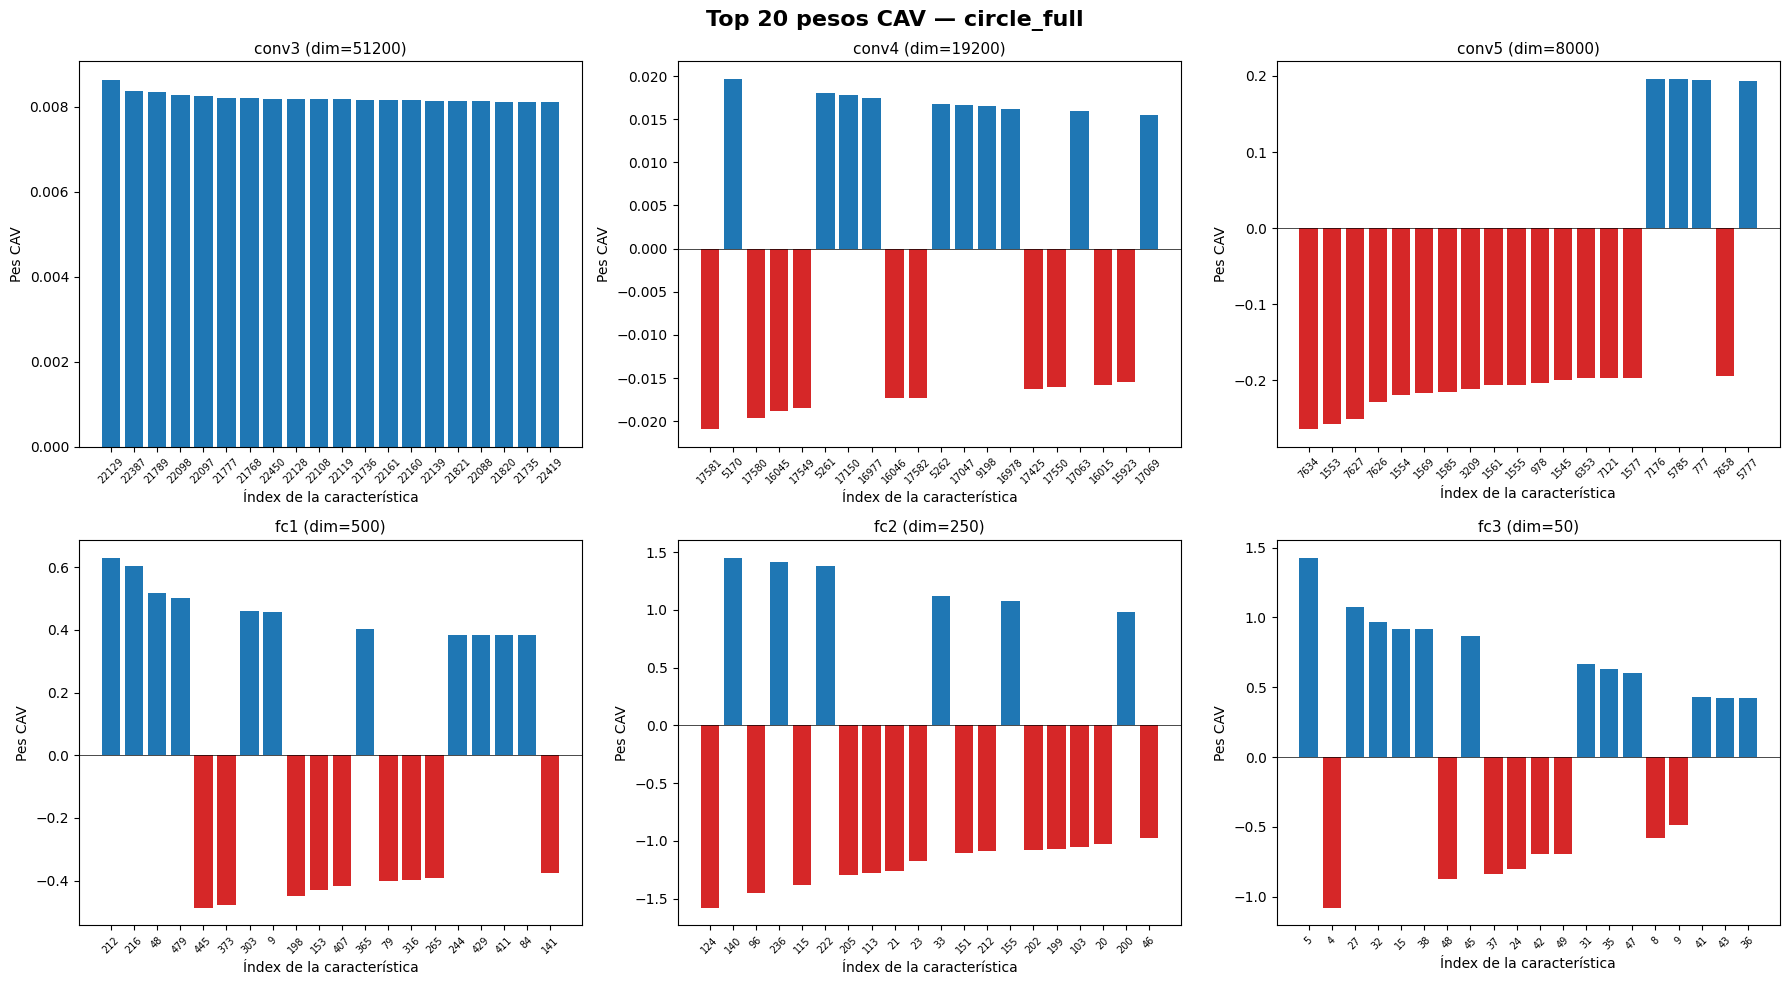

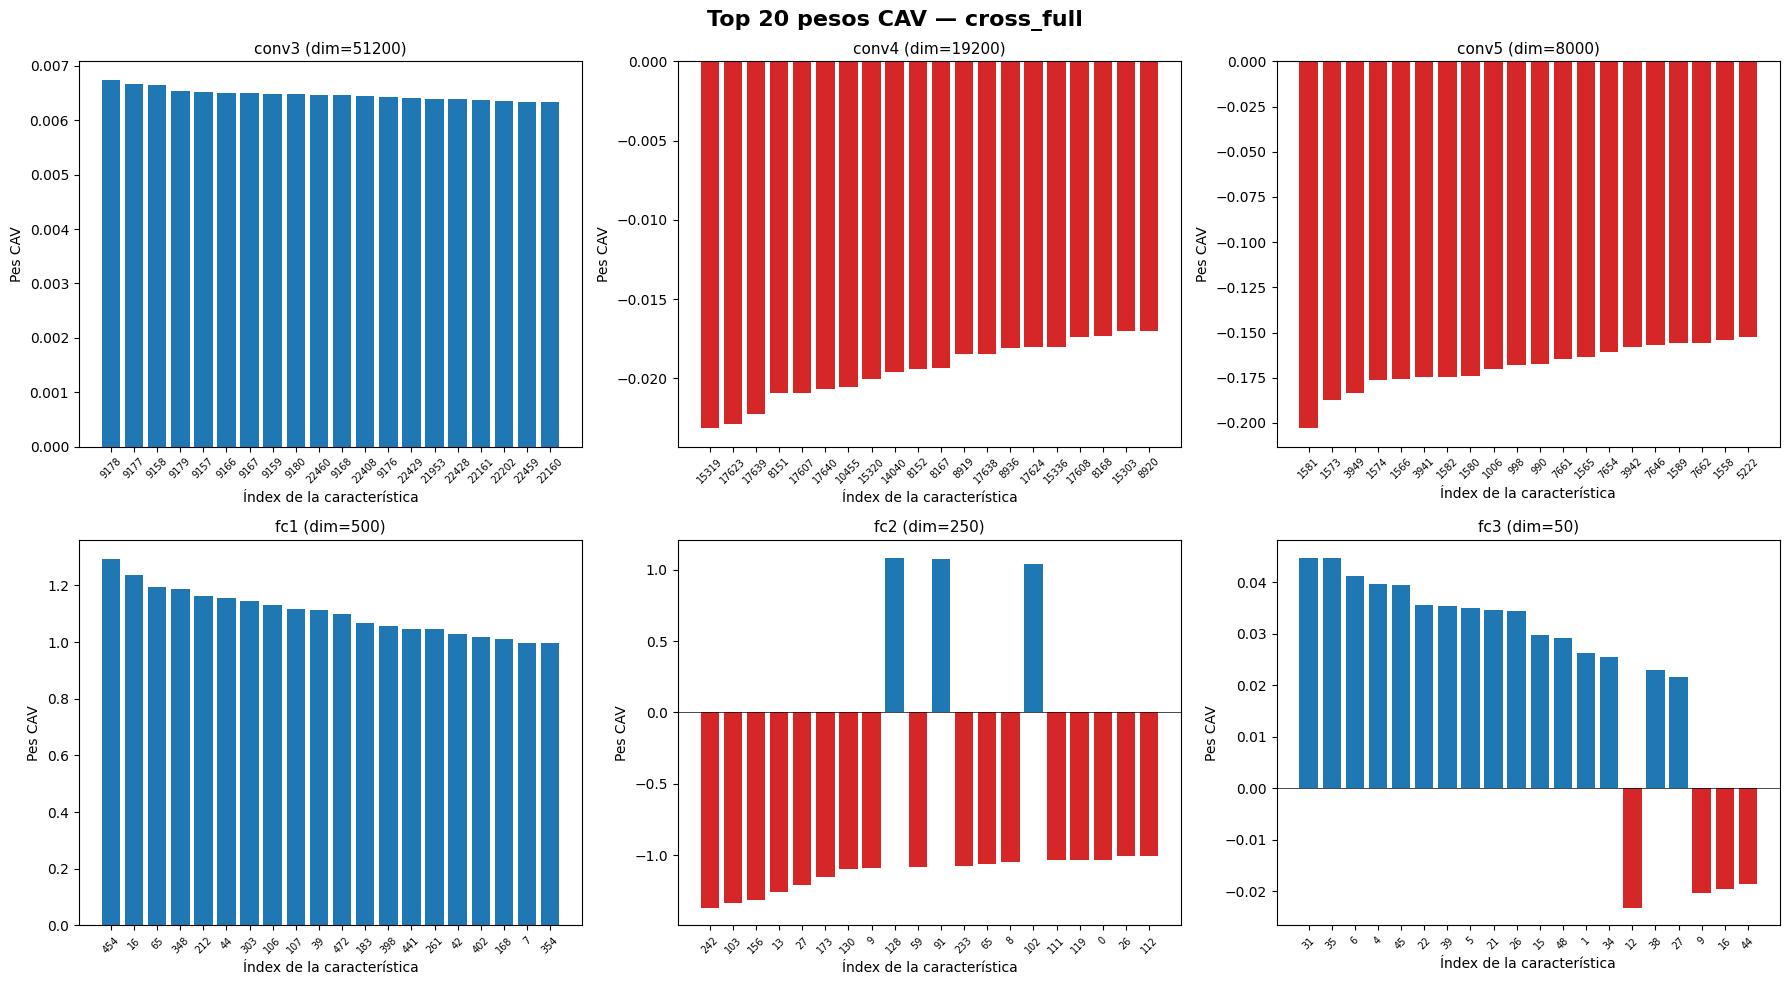

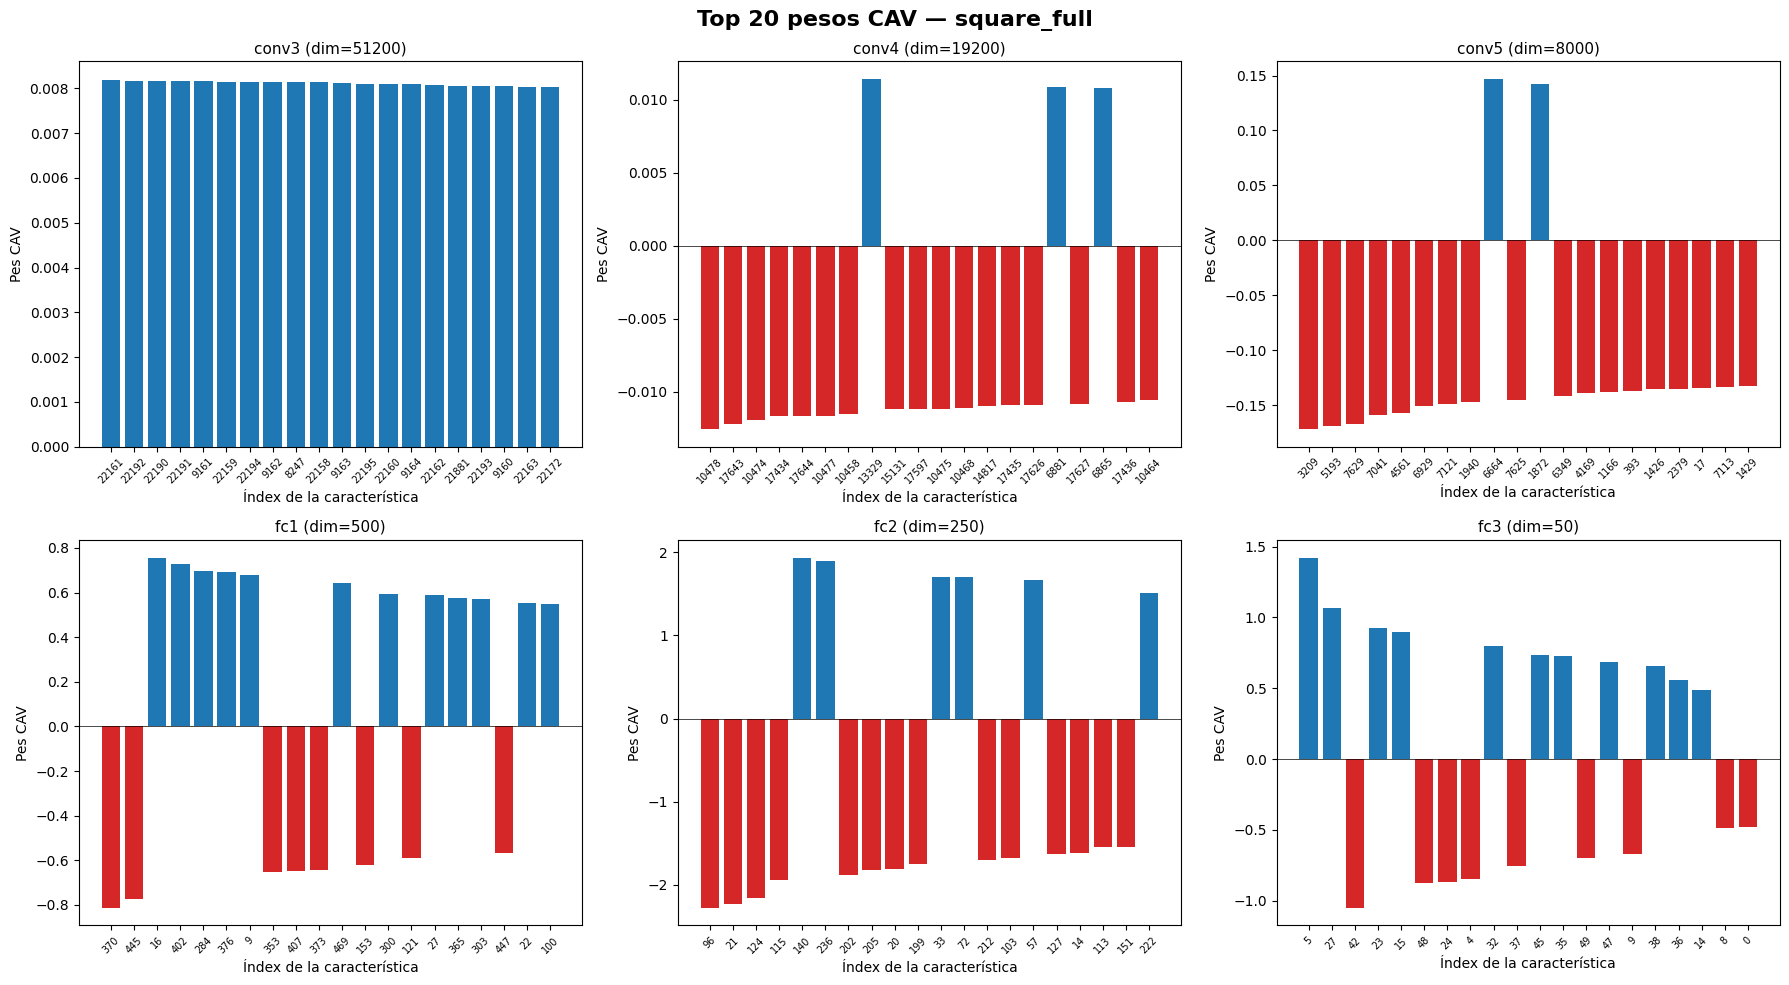

In [8]:
# =============================================
# Visualització dels Top-N pesos CAV per concepte × capa
# =============================================
TOP_N = 20

for concept_name in cav_weights:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Top {TOP_N} pesos CAV — {concept_name}", fontsize=16, fontweight='bold')
    
    for idx, layer_name in enumerate(LAYERS):
        ax = axes[idx // 3][idx % 3]
        w = cav_weights[concept_name][layer_name]
        
        sorted_idx = np.argsort(np.abs(w))[::-1][:TOP_N]
        top_w = w[sorted_idx]
        
        colors = ['tab:blue' if v >= 0 else 'tab:red' for v in top_w]
        ax.bar(range(TOP_N), top_w, color=colors)
        ax.set_xticks(range(TOP_N))
        ax.set_xticklabels(sorted_idx, rotation=45, fontsize=7)
        ax.set_title(f"{layer_name} (dim={w.shape[0]})", fontsize=11)
        ax.set_xlabel("Índex de la característica")
        ax.set_ylabel("Pes CAV")
        ax.axhline(y=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

---

## 10. Mapa de Calor Resum: Mitjana i Màxim $|w|$ per Concepte × Capa

### 10.1 Mètriques Computades

**Raonament:** Per obtenir una visió global de la intensitat de codificació de cada concepte a cada capa, calculem dues estadístiques sobre el vector CAV $\mathbf{v}_c^\ell$:

1. **Mitjana $|w|$:** Mesura la força general de la codificació del concepte. Valors alts indiquen que la direcció del concepte està ben separada de l'aleatorietat en mitjana.

$$\text{Mitjana}(|\mathbf{v}_c^\ell|) = \frac{1}{D} \sum_{d=1}^{D} |v_{c,d}^\ell|$$

2. **Màxim $|w|$:** Identifica si existeix alguna característica individual altament discriminativa.

$$\text{Max}(|\mathbf{v}_c^\ell|) = \max_{d=1,\ldots,D} |v_{c,d}^\ell|$$

### 10.2 Interpretació Esperada

- Capes convolucionals primerenques: valors petits (codificació distribuïda en alta dimensionalitat).
- Capes fully connected: valors marcadament més grans (informació comprimida en menys dimensions).
- La capa amb els valors més alts indica on la informació del concepte està **més compactament representada**.

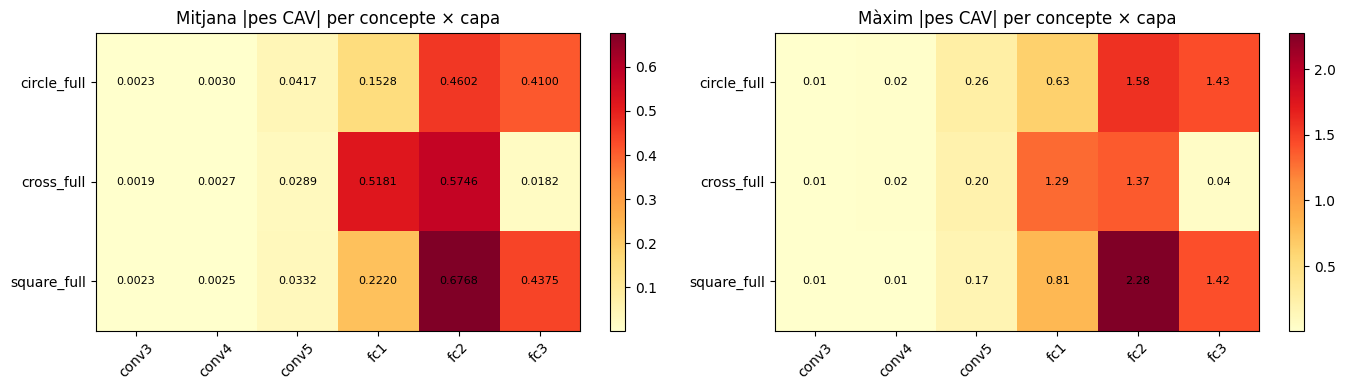

In [9]:
# =============================================
# Mapa de calor resum: mitjana i màxim |w| per concepte × capa
# =============================================
concept_names = list(cav_weights.keys())

mean_abs = np.zeros((len(concept_names), len(LAYERS)))
max_abs  = np.zeros((len(concept_names), len(LAYERS)))

for i, cn in enumerate(concept_names):
    for j, ln in enumerate(LAYERS):
        w = cav_weights[cn][ln]
        mean_abs[i, j] = np.abs(w).mean()
        max_abs[i, j]  = np.abs(w).max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

im1 = ax1.imshow(mean_abs, aspect='auto', cmap='YlOrRd')
ax1.set_xticks(range(len(LAYERS)))
ax1.set_xticklabels(LAYERS, rotation=45)
ax1.set_yticks(range(len(concept_names)))
ax1.set_yticklabels(concept_names)
ax1.set_title("Mitjana |pes CAV| per concepte × capa")
for i in range(len(concept_names)):
    for j in range(len(LAYERS)):
        ax1.text(j, i, f"{mean_abs[i,j]:.4f}", ha='center', va='center', fontsize=8)
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(max_abs, aspect='auto', cmap='YlOrRd')
ax2.set_xticks(range(len(LAYERS)))
ax2.set_xticklabels(LAYERS, rotation=45)
ax2.set_yticks(range(len(concept_names)))
ax2.set_yticklabels(concept_names)
ax2.set_title("Màxim |pes CAV| per concepte × capa")
for i in range(len(concept_names)):
    for j in range(len(LAYERS)):
        ax2.text(j, i, f"{max_abs[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

---

## 11. Puntuacions TCAV: Derivada Direccional i Influència del Concepte

### 11.1 Formulació Matemàtica

**Raonament:** Fins ara hem demostrat que els conceptes es poden separar linealment de l'aleatorietat a l'espai d'activacions (via els CAVs). Ara volem respondre una pregunta diferent:

> *El concepte $c$ influeix positivament en la predicció del model $f(\mathbf{X})$?*

Per respondre, TCAV calcula la **derivada direccional** de la sortida del model respecte a les activacions a la capa $\ell$, en la direcció del CAV:

$$S_{c,\ell}(\mathbf{X}) = \nabla_{\mathbf{a}^\ell} f(\mathbf{X}) \cdot \hat{\mathbf{v}}_c^\ell$$

on $\hat{\mathbf{v}}_c^\ell = \mathbf{v}_c^\ell / \|\mathbf{v}_c^\ell\|$ és el CAV normalitzat. Aquesta derivada mesura **quant canviaria la predicció del model si ens moguéssim en la direcció del concepte** a l'espai d'activacions.

### 11.2 Taxa TCAV

Per a un conjunt d'imatges d'entrada $\{\mathbf{X}_1, \ldots, \mathbf{X}_N\}$, la **taxa TCAV** és la fracció d'imatges amb derivada direccional positiva:

$$\text{TCAV}_{c,\ell} = \frac{|\{i : S_{c,\ell}(\mathbf{X}_i) > 0\}|}{N}$$

- $\text{TCAV}_{c,\ell} > 0.5$: El concepte $c$ **influeix positivament** la predicció a la capa $\ell$.
- $\text{TCAV}_{c,\ell} \approx 0.5$: El concepte no és més informatiu que l'atzar.
- $\text{TCAV}_{c,\ell} < 0.5$: El concepte influeix **negativament**.

### 11.3 Càrrega d'Imatges de Validació

**Raonament:** Per calcular les puntuacions TCAV, necessitem imatges d'entrada representant ambdues classes de predicció del model. Carreguem imatges de validació i les partim en:

1. **Imatges de cercle** ($\hat{y} > 0.5$): El model prediu "conté cercles".
2. **Imatges dominant-quadrat** ($\hat{y} \leq 0.5$): El model prediu "dominant en quadrats, sense cercles".

Aquesta partició permet comparar les puntuacions TCAV entre els dos règims de decisió.

In [10]:
# =============================================
# Càrrega d'imatges de validació i classificació amb el model
# =============================================
import glob as glob_mod

val_dir = "data/aixi_shape/val/"
val_paths = sorted(glob_mod.glob(val_dir + "*.png"))[:200]

val_tensors = []
for p in val_paths:
    img = Image.open(p).convert("L")
    t = transform(img)
    val_tensors.append(t)

val_batch = torch.stack(val_tensors).to(DEVICE)
with torch.no_grad():
    preds = model(val_batch).squeeze()

# Partició per predicció del model
circle_mask = preds > 0.5       # pred ≈ 1.0 → conté cercles
sq_dominant_mask = preds <= 0.5  # pred ≈ 0.0 → dominant en quadrats

print(f"Total d'imatges de validació carregades: {len(val_paths)}")
print(f"  Classificades com 'conté cercles' (>0.5): {circle_mask.sum().item()}")
print(f"  Classificades com 'dominant-quadrat' (<=0.5): {sq_dominant_mask.sum().item()}")

N_SAMPLES = 20
x_circle = val_batch[circle_mask][:N_SAMPLES]
x_sq_dominant = val_batch[sq_dominant_mask][:N_SAMPLES]

print(f"\nMostres seleccionades: cercle={x_circle.shape[0]}, dominant-quadrat={x_sq_dominant.shape[0]}")

Total d'imatges de validació carregades: 200
  Classificades com 'conté cercles' (>0.5): 138
  Classificades com 'dominant-quadrat' (<=0.5): 62

Mostres seleccionades: cercle=20, dominant-quadrat=20


### 11.4 Càlcul de les Puntuacions TCAV

**Raonament:** Executem `mytcav.interpret()` per a ambdós grups d'imatges. Captum utilitza per defecte `LayerGradientXActivation` com a mètode d'atribució, que calcula:

$$\text{attribution}_{c,\ell,d}(\mathbf{X}) = \frac{\partial f(\mathbf{X})}{\partial a_d^\ell} \cdot a_d^\ell$$

i després projecta sobre la direcció CAV per obtenir la derivada direccional.

**Hipòtesi:** Esperem veure puntuacions significatives per a les imatges dominant-quadrat (on la sigmoide no està saturada) i puntuacions nul·les per a les imatges de cercle (on $\sigma'(z) \to 0$ per $z$ gran).

In [11]:
# =============================================
# Càlcul de les puntuacions TCAV
# =============================================
mytcav_score = TCAV(model=model, layers=LAYERS)

sample_groups = {
    "imatges_cercle": x_circle,
    "imatges_dominant_quadrat": x_sq_dominant,
}

tcav_scores = {}
for group_name, x_input in sample_groups.items():
    print(f"\n=== Puntuacions TCAV per '{group_name}' (batch={x_input.shape[0]}) ===")
    scores = mytcav_score.interpret(
        inputs=x_input,
        experimental_sets=experimental_sets,
        target=0,
    )
    tcav_scores[group_name] = scores
    
    for exp_key, layer_data in scores.items():
        concept_name = key_to_concept.get(exp_key, exp_key)
        print(f"\n  {concept_name} ({exp_key}):")
        for layer_name, stats in layer_data.items():
            sc = stats.get('sign_count', None)
            if sc is not None:
                pos, neg = sc[0].item(), sc[1].item()
                total = pos + neg
                rate = pos / total if total > 0 else 0
                print(f"    {layer_name}: positius={pos:.0f}, negatius={neg:.0f}, taxa={rate:.2f}")


=== Puntuacions TCAV per 'imatges_cercle' (batch=20) ===


/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()



  circle_full (0-100):
    conv3: positius=0, negatius=0, taxa=0.00
    conv4: positius=0, negatius=0, taxa=0.00
    conv5: positius=0, negatius=0, taxa=0.00
    fc1: positius=0, negatius=0, taxa=0.00
    fc2: positius=0, negatius=0, taxa=0.00
    fc3: positius=0, negatius=0, taxa=0.00

  cross_full (1-100):
    conv3: positius=0, negatius=0, taxa=0.00
    conv4: positius=0, negatius=0, taxa=0.00
    conv5: positius=0, negatius=0, taxa=0.00
    fc1: positius=0, negatius=0, taxa=0.00
    fc2: positius=0, negatius=0, taxa=0.00
    fc3: positius=0, negatius=0, taxa=0.00

  square_full (2-100):
    conv3: positius=0, negatius=0, taxa=0.00
    conv4: positius=0, negatius=0, taxa=0.00
    conv5: positius=0, negatius=0, taxa=0.00
    fc1: positius=0, negatius=0, taxa=0.00
    fc2: positius=0, negatius=0, taxa=0.00
    fc3: positius=0, negatius=0, taxa=0.00

=== Puntuacions TCAV per 'imatges_dominant_quadrat' (batch=20) ===

  circle_full (0-100):
    conv3: positius=1, negatius=0, taxa=0.85


---

## 12. Diagnòstic: Saturació de la Sigmoide i Fallada de TCAV

### 12.1 Anàlisi Matemàtica del Problema

**Observació clau:** Per a les imatges de cercle (prediccions $\hat{y} \approx 1.0$), **totes** les puntuacions TCAV són exactament zero a totes les capes i conceptes. Això no és un artefacte — és una conseqüència matemàtica de la sigmoide a la sortida.

Recordem que la sigmoide i la seva derivada són:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)$$

Quan el model és molt confiat ($\hat{y} = \sigma(z) \approx 1.0$), el logit pre-sigmoide $z$ és molt gran, i:

$$\sigma'(z) = \sigma(z)(1 - \sigma(z)) \approx 1.0 \cdot (1 - 1.0) = 0$$

Com que la puntuació TCAV depèn del gradient que flueix des de la sortida a través de la sigmoide:

$$S_{c,\ell}(\mathbf{X}) = \underbrace{\frac{\partial f}{\partial \mathbf{a}^\ell}}_{\text{inclou } \sigma'(z)} \cdot \hat{\mathbf{v}}_c^\ell \approx 0$$

**Conclusió:** TCAV és **inherentment no fiable** per a models amb sortida sigmoide quan les prediccions estan saturades. Això afecta tant la saturació positiva ($\hat{y} \approx 1$) com la negativa ($\hat{y} \approx 0$).

### 12.2 Resultats per a Imatges Dominant-Quadrat

Per a les imatges amb prediccions en la **zona de transició** de la sigmoide ($0 < \hat{y} < 1$, on $\sigma'(z) > 0$), observem puntuacions TCAV significatives:

- Les taxes altes a les capes convolucionals (`conv3`–`conv5`) indiquen que la sensibilitat al concepte, mesurada pel gradient, es localitza en les etapes d'extracció de característiques espacials.
- Les taxes zero a les capes FC suggereixen que el gradient de TCAV no capta la influència del concepte un cop l'estructura espacial s'ha col·lapsat.

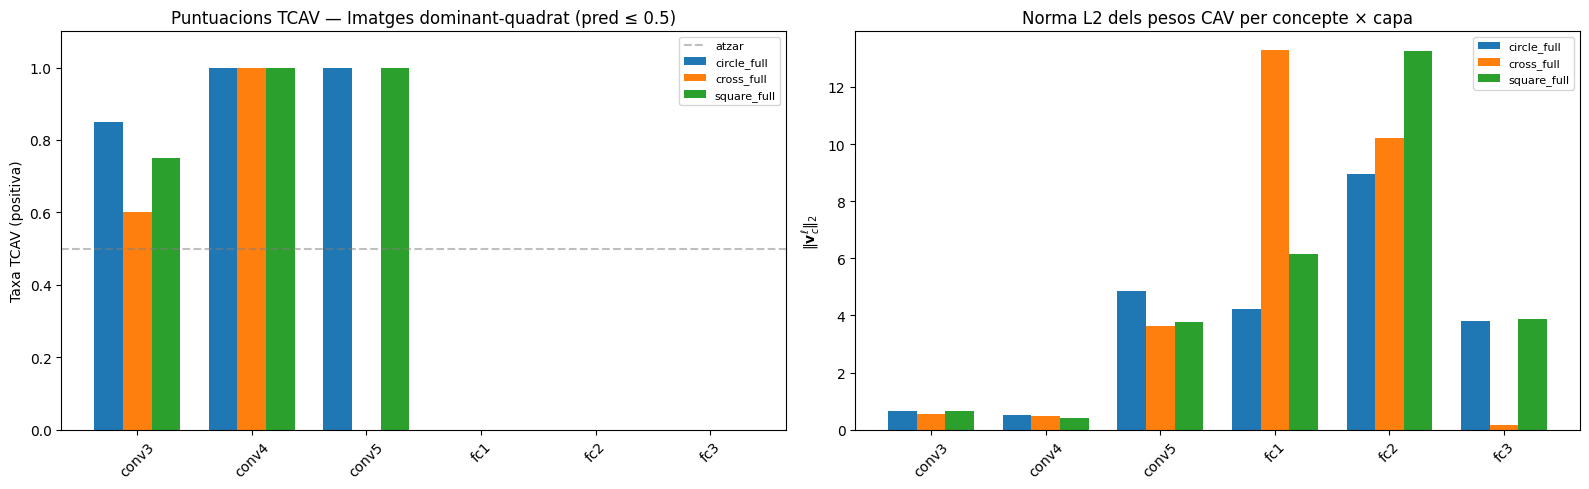

In [12]:
# =============================================
# Visualització: Taxes TCAV i normes CAV
# =============================================
concept_names_list = ['circle_full', 'cross_full', 'square_full']
exp_keys = ['0-100', '1-100', '2-100']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gràfic 1: Taxes TCAV (només imatges dominant-quadrat)
ax = axes[0]
x_pos = np.arange(len(LAYERS))
width = 0.25

scores_data = tcav_scores['imatges_dominant_quadrat']
for i, (ek, cn) in enumerate(zip(exp_keys, concept_names_list)):
    rates = []
    for layer in LAYERS:
        sc = scores_data[ek][layer]['sign_count']
        pos, neg = sc[0].item(), sc[1].item()
        total = pos + neg
        rates.append(pos / total if total > 0 else 0)
    ax.bar(x_pos + i * width, rates, width, label=cn)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(LAYERS, rotation=45)
ax.set_ylabel('Taxa TCAV (positiva)')
ax.set_title('Puntuacions TCAV — Imatges dominant-quadrat (pred ≤ 0.5)')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='atzar')
ax.legend(fontsize=8)

# Gràfic 2: Normes L2 dels pesos CAV
ax2 = axes[1]
for i, cn in enumerate(concept_names_list):
    norms = [np.linalg.norm(cav_weights[cn][l]) for l in LAYERS]
    ax2.bar(x_pos + i * width, norms, width, label=cn)

ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(LAYERS, rotation=45)
ax2.set_ylabel('$\\|\\mathbf{v}_c^\\ell\\|_2$')
ax2.set_title('Norma L2 dels pesos CAV per concepte × capa')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 12.3 Divergència entre Taxes TCAV i Normes CAV

**Observació important:** Les normes CAV ($\|\mathbf{v}_c^\ell\|_2$) són altes a les capes convolucionals (espais d'alta dimensió) i disminueixen a les capes FC, mentre que les taxes TCAV són altes només a les capes conv.

Aquesta **divergència** revela que les taxes TCAV i les normes CAV mesuren propietats fonamentalment diferents:

| Mètrica | Mesura | Depèn de |
|---------|--------|----------|
| Taxa TCAV | Sensibilitat basada en gradient | Gradient de la sortida |
| Norma CAV | Separabilitat lineal | Només activacions |

Les normes CAV altes a les capes convolucionals reflecteixen la **alta dimensionalitat** de l'espai (el classificador necessita pesos distribuïts sobre moltes dimensions), no necessàriament una codificació més forta del concepte.

---

## 13. Visualització de Mapes d'Activació Intermedis (Feature Maps)

### 13.1 Metodologia: Forward Hooks

**Raonament:** Per visualitzar les representacions internes que TNet construeix quan processa imatges de conceptes, necessitem capturar les **activacions intermèdies** a cada capa de MaxPool.

PyTorch proporciona l'API `register_forward_hook` que permet registrar funcions *callback* que s'executen automàticament durant la passada endavant (*forward pass*). Cada hook:

1. Intercepta la sortida del mòdul `MaxPool2d`.
2. Emmagatzema el tensor d'activacions (desconnectat del graf computacional amb `detach()`) en un diccionari global.

**Formes de les activacions capturades:**

| Capa MaxPool | Canals $C$ | Dimensions Espacials $H \times W$ | Naturalesa |
|-------------|------------|----------------------------------|------------|
| `maxpool1` | 25 | $64 \times 64$ | Característiques de baix nivell (vores, textures) |
| `maxpool2` | 35 | $32 \times 32$ | Patrons locals de nivell mig |
| `maxpool3` | 50 | $16 \times 16$ | Fragments de formes d'alt ordre |
| `maxpool4` | 75 | $8 \times 8$ | Representacions abstractes de formes |
| `maxpool5` | 125 | $4 \times 4$ | Característiques globals altament comprimides |

### 13.2 Mapa de Calor d'Activació Mitjana

Per visualitzar l'atenció espacial d'una capa, calculem la **mitjana sobre tots els canals** a cada posició espacial:

$$\bar{A}(h, w) = \frac{1}{C} \sum_{c=1}^{C} A_{c,h,w}$$

Això produeix un mapa 2D que indica quines regions de la imatge activen més fortament les neurones de la capa, independentment del canal específic.

In [13]:
# =============================================
# Registre de forward hooks a les capes MaxPool
# =============================================
activations = {}

def make_hook(name):
    def hook_fn(module, input, output):
        activations[name] = output.detach()
    return hook_fn

hook_layers = {
    'maxpool1': model.maxpool1,
    'maxpool2': model.maxpool2,
    'maxpool3': model.maxpool3,
    'maxpool4': model.maxpool4,
    'maxpool5': model.maxpool5,
}

hooks = []
for name, layer in hook_layers.items():
    hooks.append(layer.register_forward_hook(make_hook(name)))

print(f"Registrats {len(hooks)} forward hooks a les capes MaxPool.")

Registrats 5 forward hooks a les capes MaxPool.


In [14]:
# =============================================
# Passada endavant amb imatges representatives de cada concepte
# =============================================
import glob as glob_mod

concept_samples = {}
concepts_path = "./data/concepts"

for concept_name in ['circle_full', 'cross_full', 'square_full']:
    img_paths = sorted(glob_mod.glob(os.path.join(concepts_path, concept_name, "*.png")))
    if not img_paths:
        img_paths = sorted(glob_mod.glob(os.path.join(concepts_path, concept_name, "*.jpg")))
    
    img = Image.open(img_paths[0]).convert("L")
    t = transform(img).unsqueeze(0).to(DEVICE)
    
    activations.clear()
    with torch.no_grad():
        pred = model(t)
    
    concept_samples[concept_name] = {
        'image': img,
        'tensor': t,
        'pred': pred.item(),
        'activations': dict(activations),
    }
    
    print(f"{concept_name}: predicció={pred.item():.4f}, formes de les activacions:")
    for layer_name, act in concept_samples[concept_name]['activations'].items():
        print(f"  {layer_name}: {act.shape}")

circle_full: predicció=1.0000, formes de les activacions:
  maxpool1: torch.Size([1, 25, 64, 64])
  maxpool2: torch.Size([1, 35, 32, 32])
  maxpool3: torch.Size([1, 50, 16, 16])
  maxpool4: torch.Size([1, 75, 8, 8])
  maxpool5: torch.Size([1, 125, 4, 4])
cross_full: predicció=0.0000, formes de les activacions:
  maxpool1: torch.Size([1, 25, 64, 64])
  maxpool2: torch.Size([1, 35, 32, 32])
  maxpool3: torch.Size([1, 50, 16, 16])
  maxpool4: torch.Size([1, 75, 8, 8])
  maxpool5: torch.Size([1, 125, 4, 4])
square_full: predicció=0.0000, formes de les activacions:
  maxpool1: torch.Size([1, 25, 64, 64])
  maxpool2: torch.Size([1, 35, 32, 32])
  maxpool3: torch.Size([1, 50, 16, 16])
  maxpool4: torch.Size([1, 75, 8, 8])
  maxpool5: torch.Size([1, 125, 4, 4])


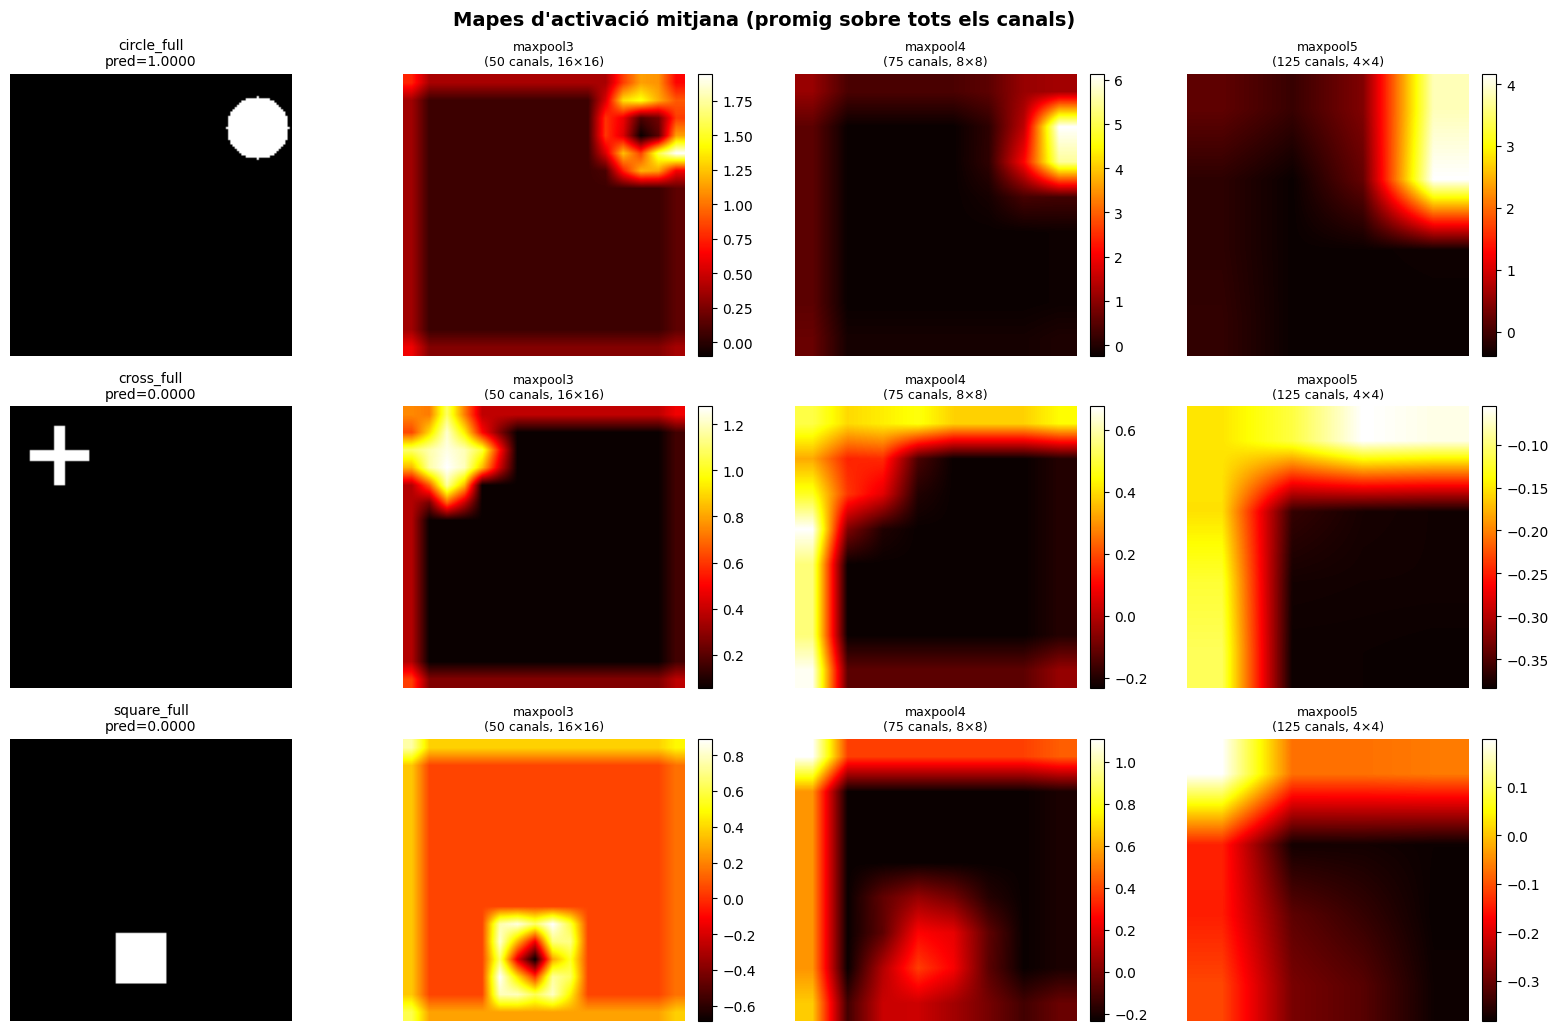

In [15]:
# =============================================
# Visualització: Mapes d'activació mitjana per concepte × capa MaxPool
# =============================================
concept_names_list = ['circle_full', 'cross_full', 'square_full']
layer_names = ['maxpool3', 'maxpool4', 'maxpool5']

fig, axes = plt.subplots(len(concept_names_list), len(layer_names) + 1, 
                         figsize=(16, 3.5 * len(concept_names_list)))

for i, cn in enumerate(concept_names_list):
    # Imatge original
    ax = axes[i][0]
    ax.imshow(concept_samples[cn]['image'], cmap='gray')
    ax.set_title(f"{cn}\npred={concept_samples[cn]['pred']:.4f}", fontsize=10)
    ax.axis('off')
    
    # Mapes d'activació mitjana per a cada capa
    for j, ln in enumerate(layer_names):
        ax = axes[i][j + 1]
        act = concept_samples[cn]['activations'][ln]  # [1, C, H, W]
        mean_act = act[0].mean(dim=0).numpy()  # Mitjana sobre canals → [H, W]
        
        im = ax.imshow(mean_act, cmap='hot', interpolation='bilinear')
        ax.set_title(f"{ln}\n({act.shape[1]} canals, {act.shape[2]}×{act.shape[3]})", fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Mapes d'activació mitjana (promig sobre tots els canals)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 14. Activacions dels Canals Més Importants segons el CAV

### 14.1 Motivació i Metodologia

**Raonament:** El mapa d'activació mitjana (secció anterior) promitja sobre tots els canals, la qual cosa pot diluir la informació específica del concepte. Volem identificar **quins canals específics** són més rellevants per a cada concepte, segons els pesos del CAV.

**Mètode:** Per a cada parell (concepte $c$, capa convolucional $\ell$):

1. Reformem el vector de pesos CAV aplanat a la forma $[C, H \cdot W]$, on $C$ és el nombre de canals.
2. Calculem la **importància per canal** com la mitjana del valor absolut dels pesos sobre totes les posicions espacials:

$$\text{importància}(c) = \frac{1}{|S|} \sum_{s \in S} |w_{c,s}|$$

on $S$ representa les posicions espacials i $w_{c,s}$ és el pes CAV per al canal $c$ a la posició $s$.

3. Seleccionem els $K = 5$ canals amb importància més alta.
4. Visualitzem els seus mapes d'activació individuals.

### 14.2 Interpretació

Aquesta anàlisi **connecta el vector CAV abstracte amb els mapes d'activació espacials**. Respon la pregunta:

> *Quins filtres apresos per la xarxa són més responsables de codificar aquest concepte?*

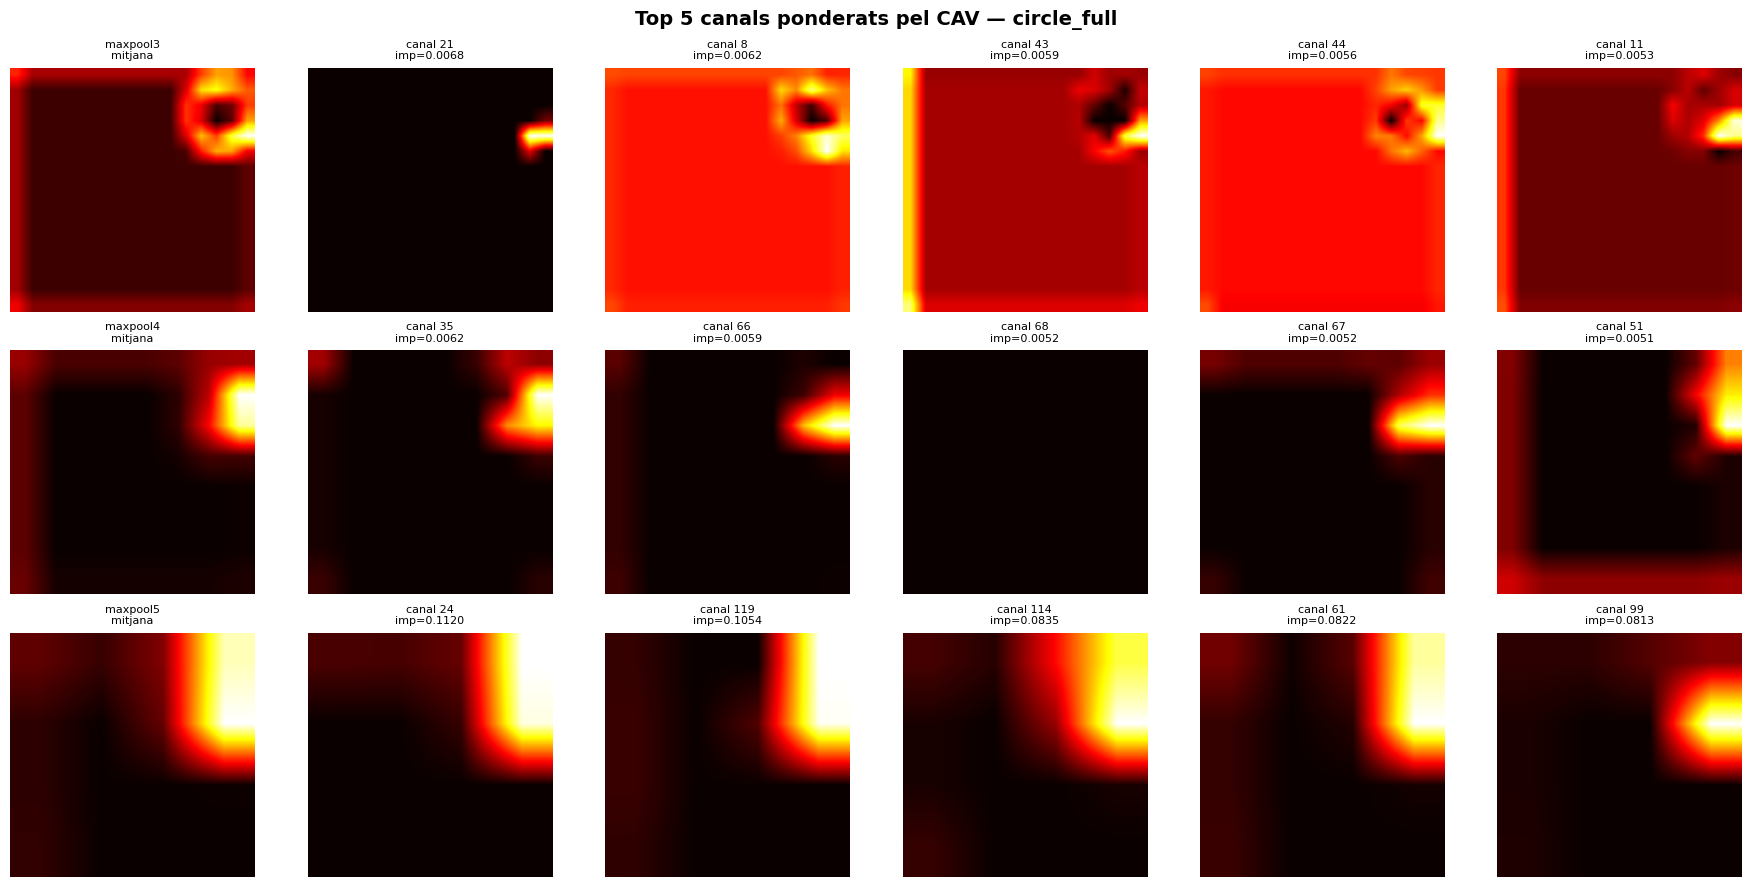

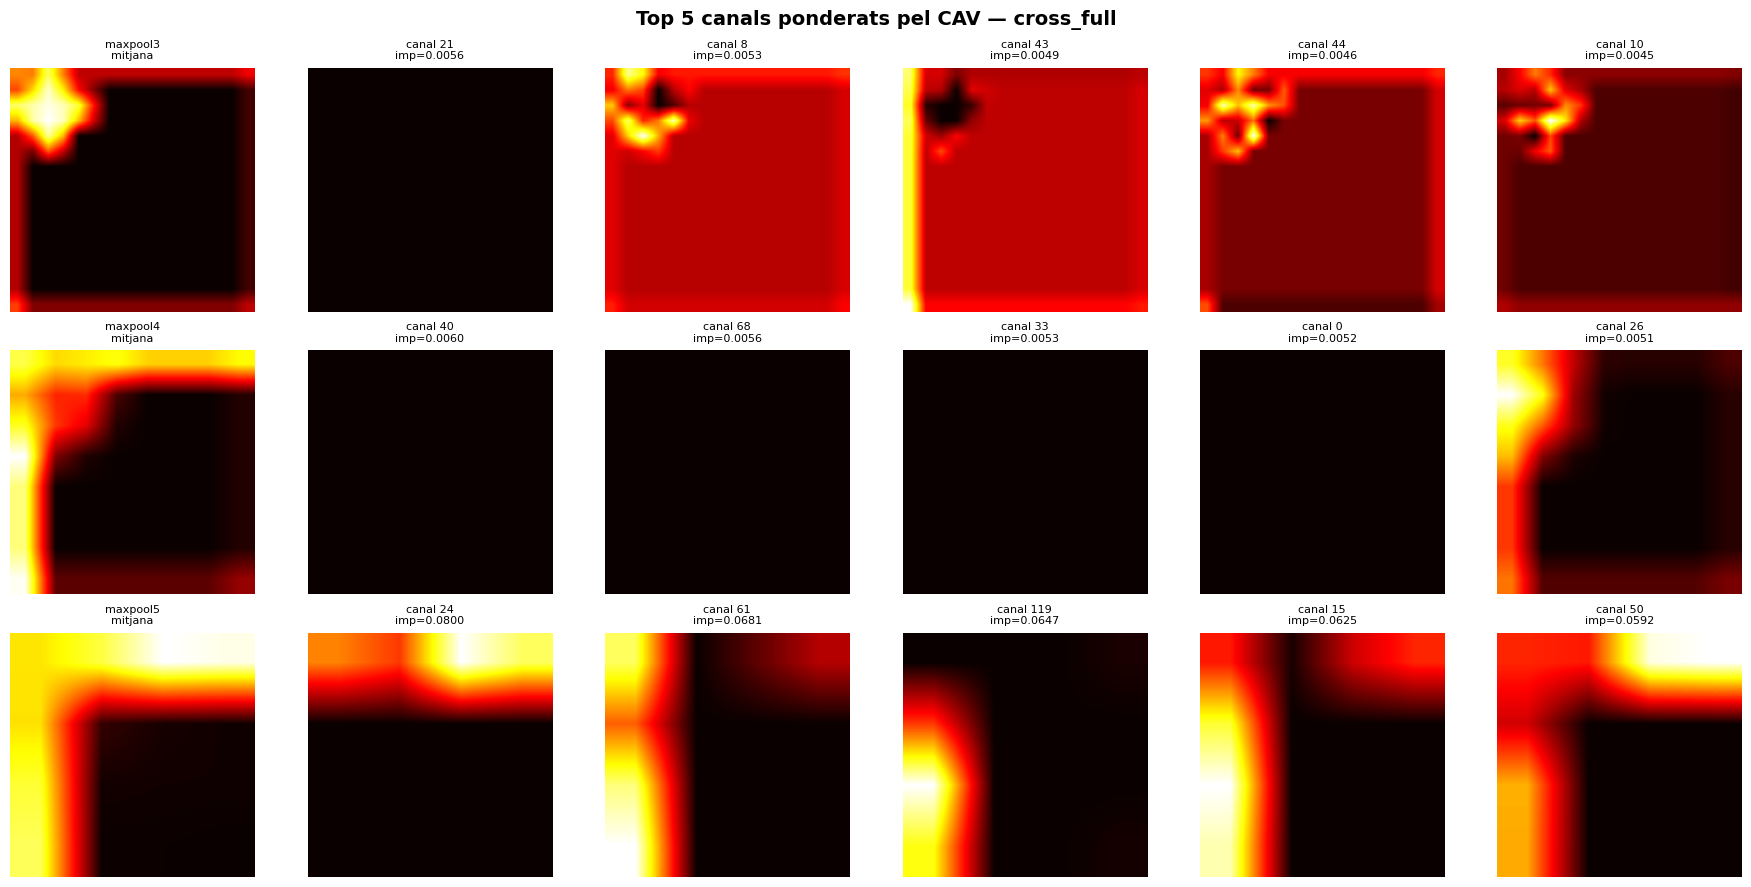

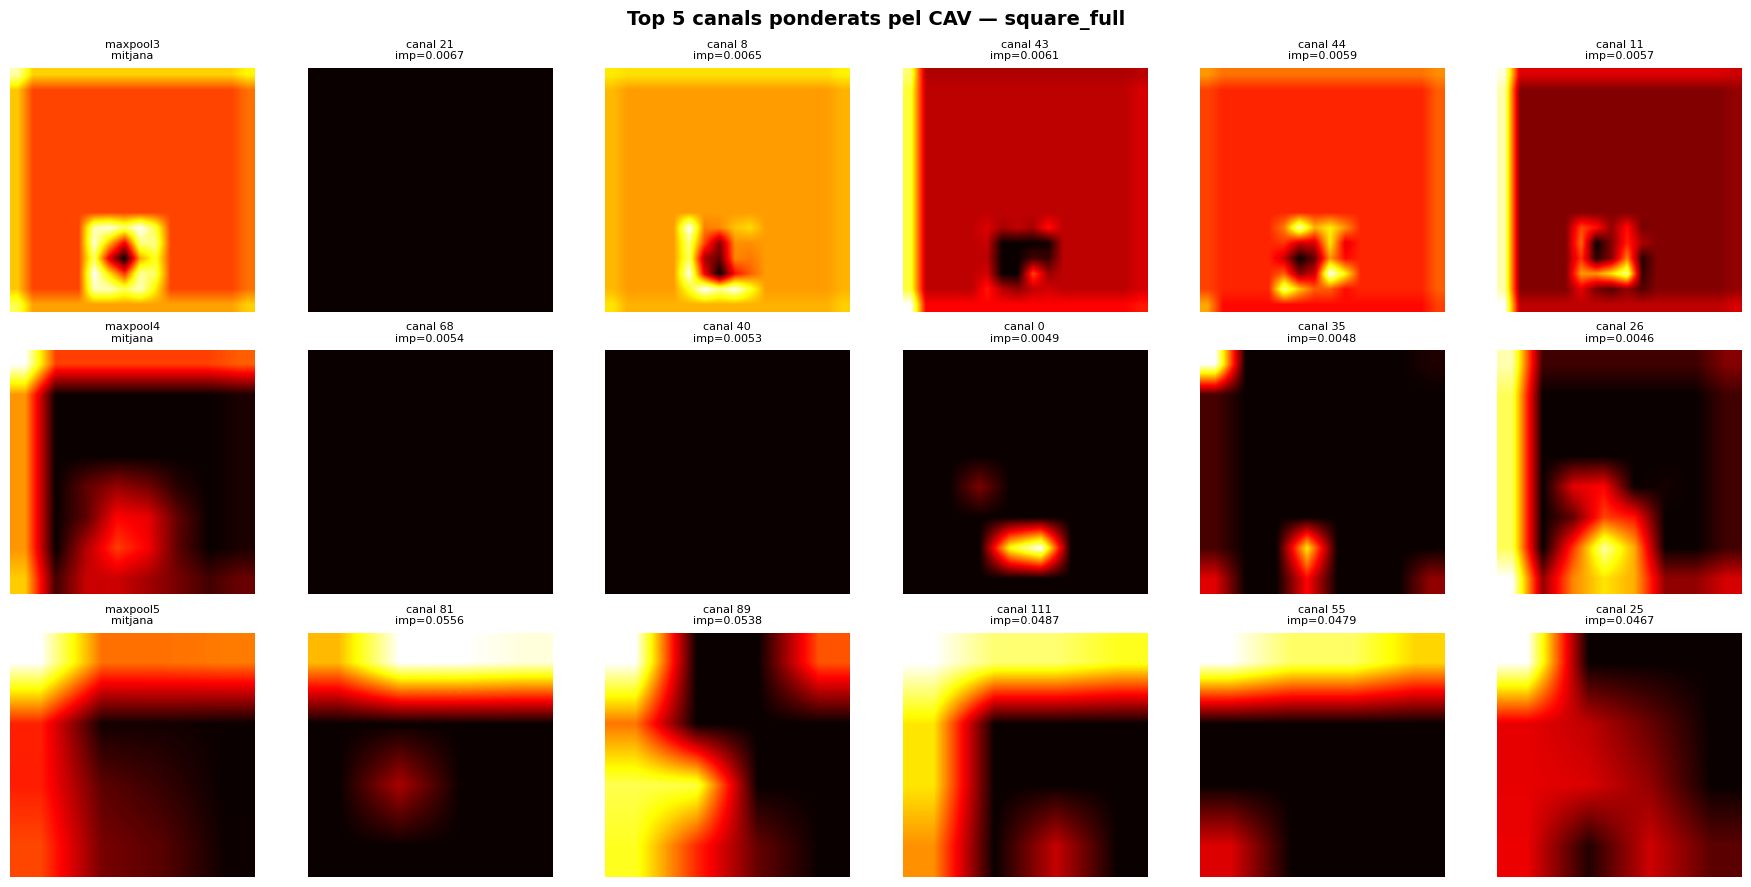

In [16]:
# =============================================
# Top-K canals més importants segons els pesos CAV
# =============================================
maxpool_to_cav = {
    'maxpool3': ('conv3', 50),
    'maxpool4': ('conv4', 75),
    'maxpool5': ('conv5', 125),
}

TOP_K = 5

for cn in concept_names_list:
    fig, axes = plt.subplots(len(maxpool_to_cav), TOP_K + 1, 
                             figsize=(3 * (TOP_K + 1), 3 * len(maxpool_to_cav)))
    fig.suptitle(f"Top {TOP_K} canals ponderats pel CAV — {cn}", fontsize=14, fontweight='bold')
    
    for row, (mp_layer, (cav_layer, n_channels)) in enumerate(maxpool_to_cav.items()):
        act = concept_samples[cn]['activations'][mp_layer]  # [1, C, H, W]
        
        w = cav_weights[cn][cav_layer]
        spatial_size = len(w) // n_channels
        w_reshaped = w.reshape(n_channels, spatial_size)
        channel_importance = np.abs(w_reshaped).mean(axis=1)
        
        top_channels = np.argsort(channel_importance)[::-1][:TOP_K]
        
        # Columna 0: activació mitjana
        ax = axes[row][0]
        mean_act = act[0].mean(dim=0).numpy()
        ax.imshow(mean_act, cmap='hot', interpolation='bilinear')
        ax.set_title(f"{mp_layer}\nmitjana", fontsize=8)
        ax.axis('off')
        
        # Columnes 1..K: activacions dels top canals
        for k, ch_idx in enumerate(top_channels):
            ax = axes[row][k + 1]
            ch_act = act[0, ch_idx].numpy()
            ax.imshow(ch_act, cmap='hot', interpolation='bilinear')
            ax.set_title(f"canal {ch_idx}\nimp={channel_importance[ch_idx]:.4f}", fontsize=8)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    print()

---

## 15. Mapes de Calor de Conceptes per Projecció CAV

### 15.1 Formulació Matemàtica

**Raonament:** Fins ara hem vist:
- Les puntuacions TCAV (secció 11) ens diuen *si* un concepte influeix globalment.
- Les activacions per canal (secció 14) ens mostren quins filtres són importants.

Ara volem generar un mapa de calor que mostri **on exactament** a la imatge d'entrada es detecten les característiques d'un concepte. La idea és projectar els pesos CAV sobre l'espai d'activacions per crear un **mapa de localització espacial del concepte**.

**Formulació:** Per a una capa convolucional amb $C$ canals i dimensions espacials $H \times W$, el vector de pesos CAV es reforma a $\mathbf{W} \in \mathbb{R}^{C \times (H \cdot W)}$. La **importància signada per canal** és:

$$\text{importància}(c) = \frac{1}{|S|} \sum_{s} W_{c,s}$$

El mapa de calor del concepte per a una imatge d'entrada es calcula com:

$$\boxed{\text{heatmap}(h, w) = \sum_{c=1}^{C} \text{importància}(c) \cdot A_{c,h,w}}$$

on $A_{c,h,w}$ és l'activació del canal $c$ a la posició espacial $(h, w)$ després de la capa MaxPool corresponent.

### 15.2 Avantatge Clau: Independència del Gradient

**Observació fonamental:** Aquest mapa de calor **no depèn del gradient de la sortida**. Depèn únicament de:
- Les activacions intermèdies $A_{c,h,w}$ (passada endavant).
- Els pesos CAV $W_{c,s}$ (classificador lineal pre-entrenat).

Això significa que la projecció CAV **funciona fins i tot quan la sigmoide està saturada** ($\hat{y} \approx 1.0$), circumventant la limitació que invalida les puntuacions TCAV.

### 15.3 Procediment de Visualització

1. Es calcula el mapa de calor a la resolució de la capa MaxPool.
2. S'aplica interpolació bilineal per redimensionar a $128 \times 128$ (resolució original).
3. Se superposa a la imatge original amb mapa de colors `jet` i transparència.

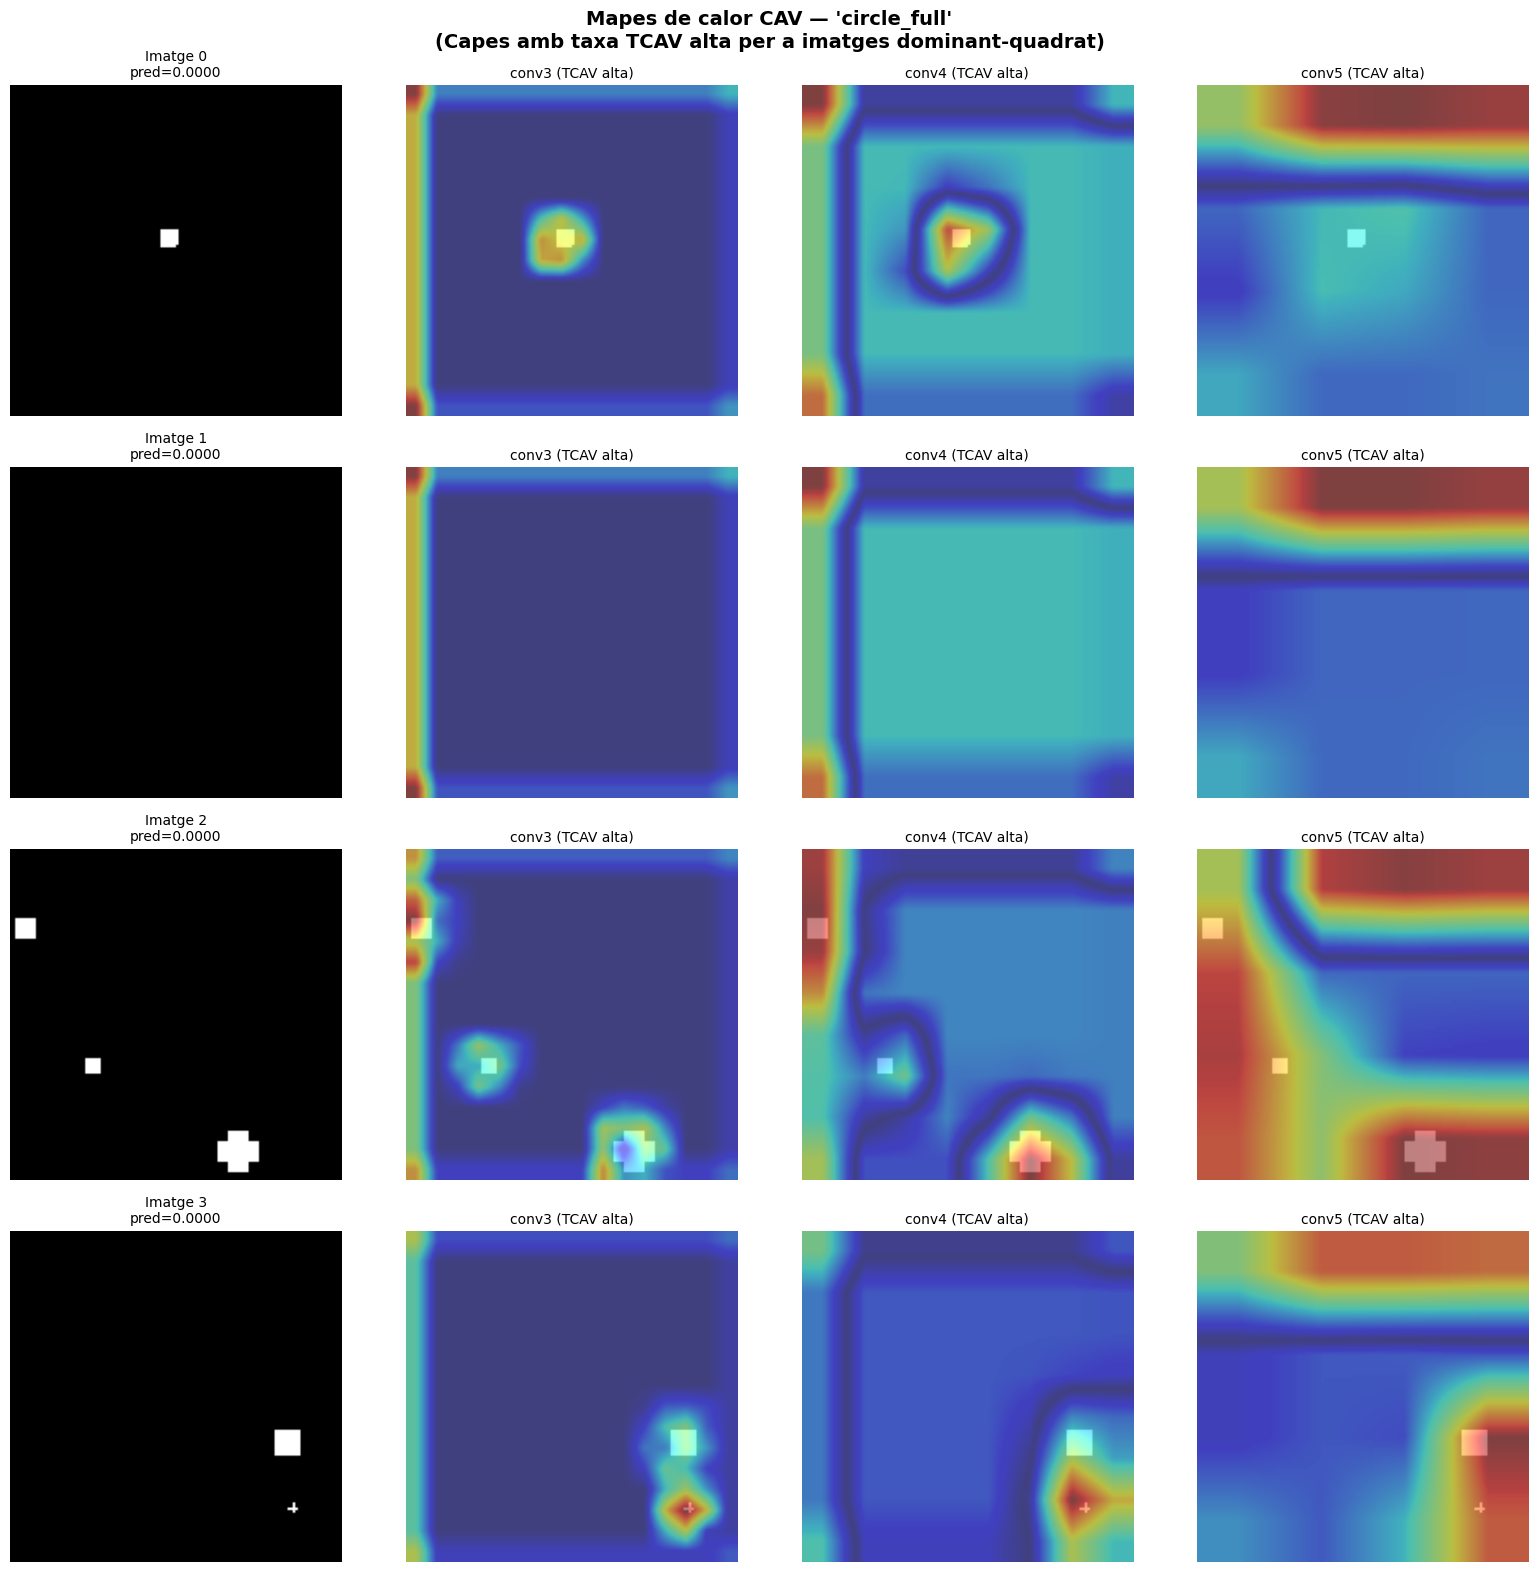

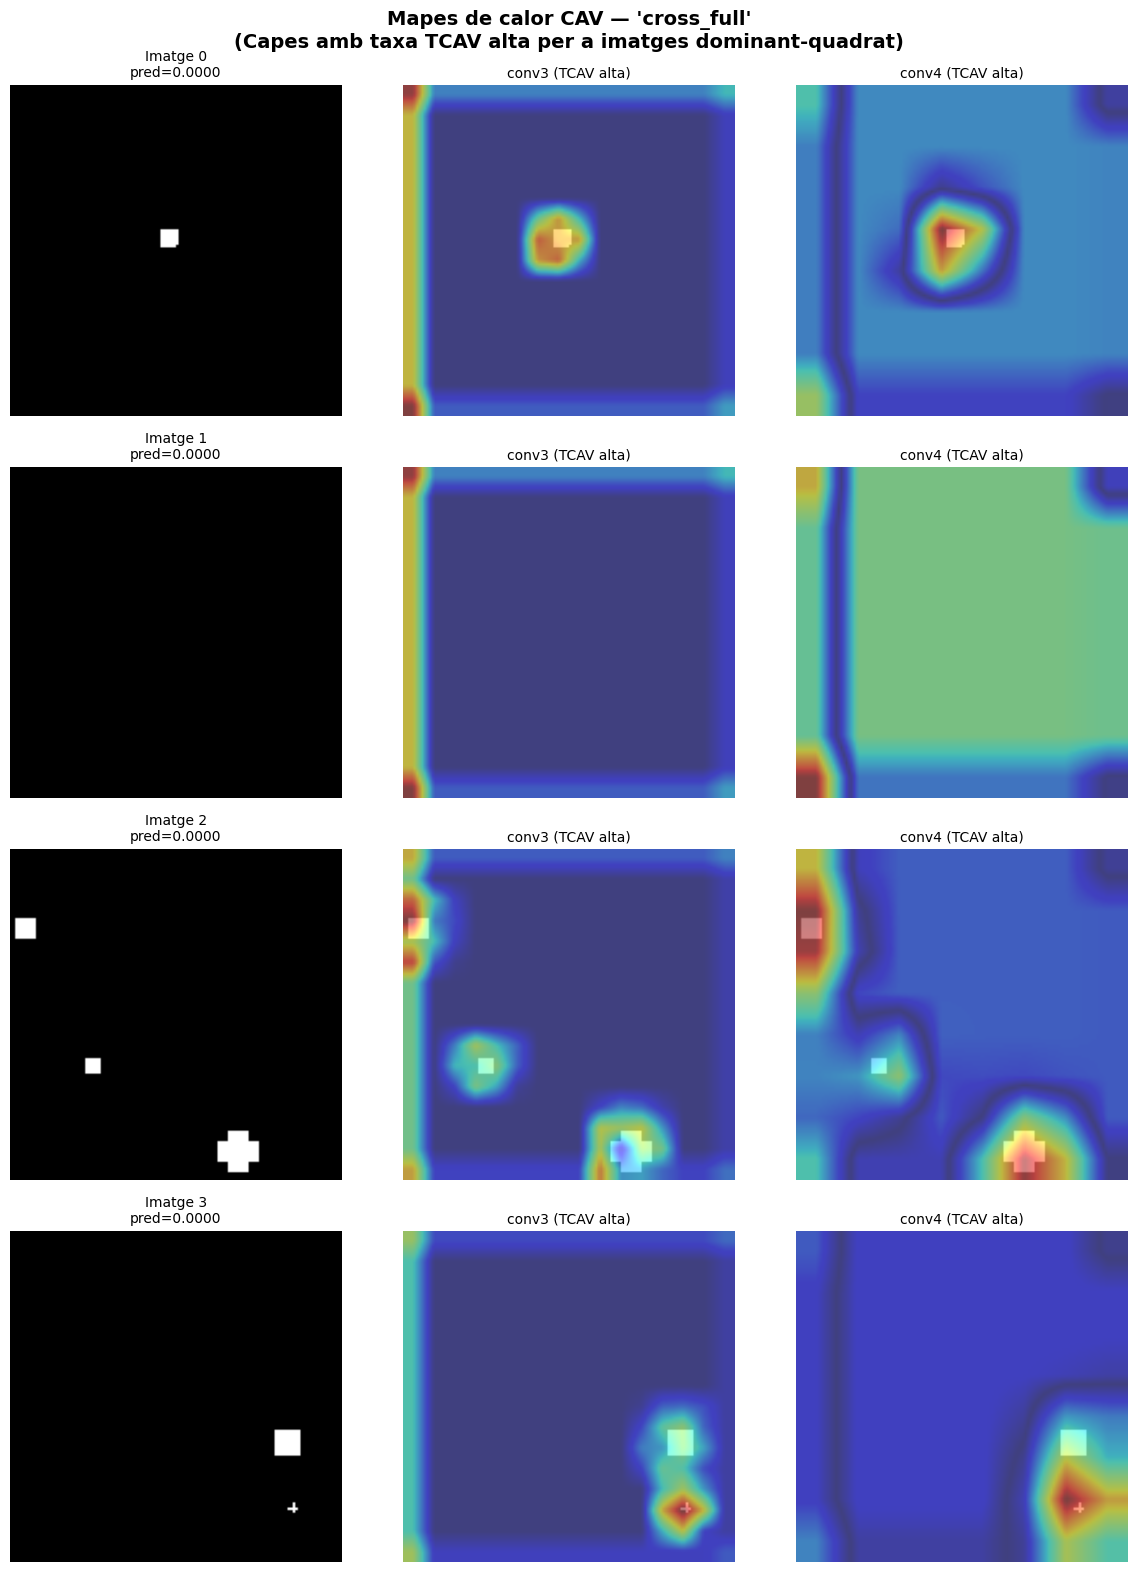

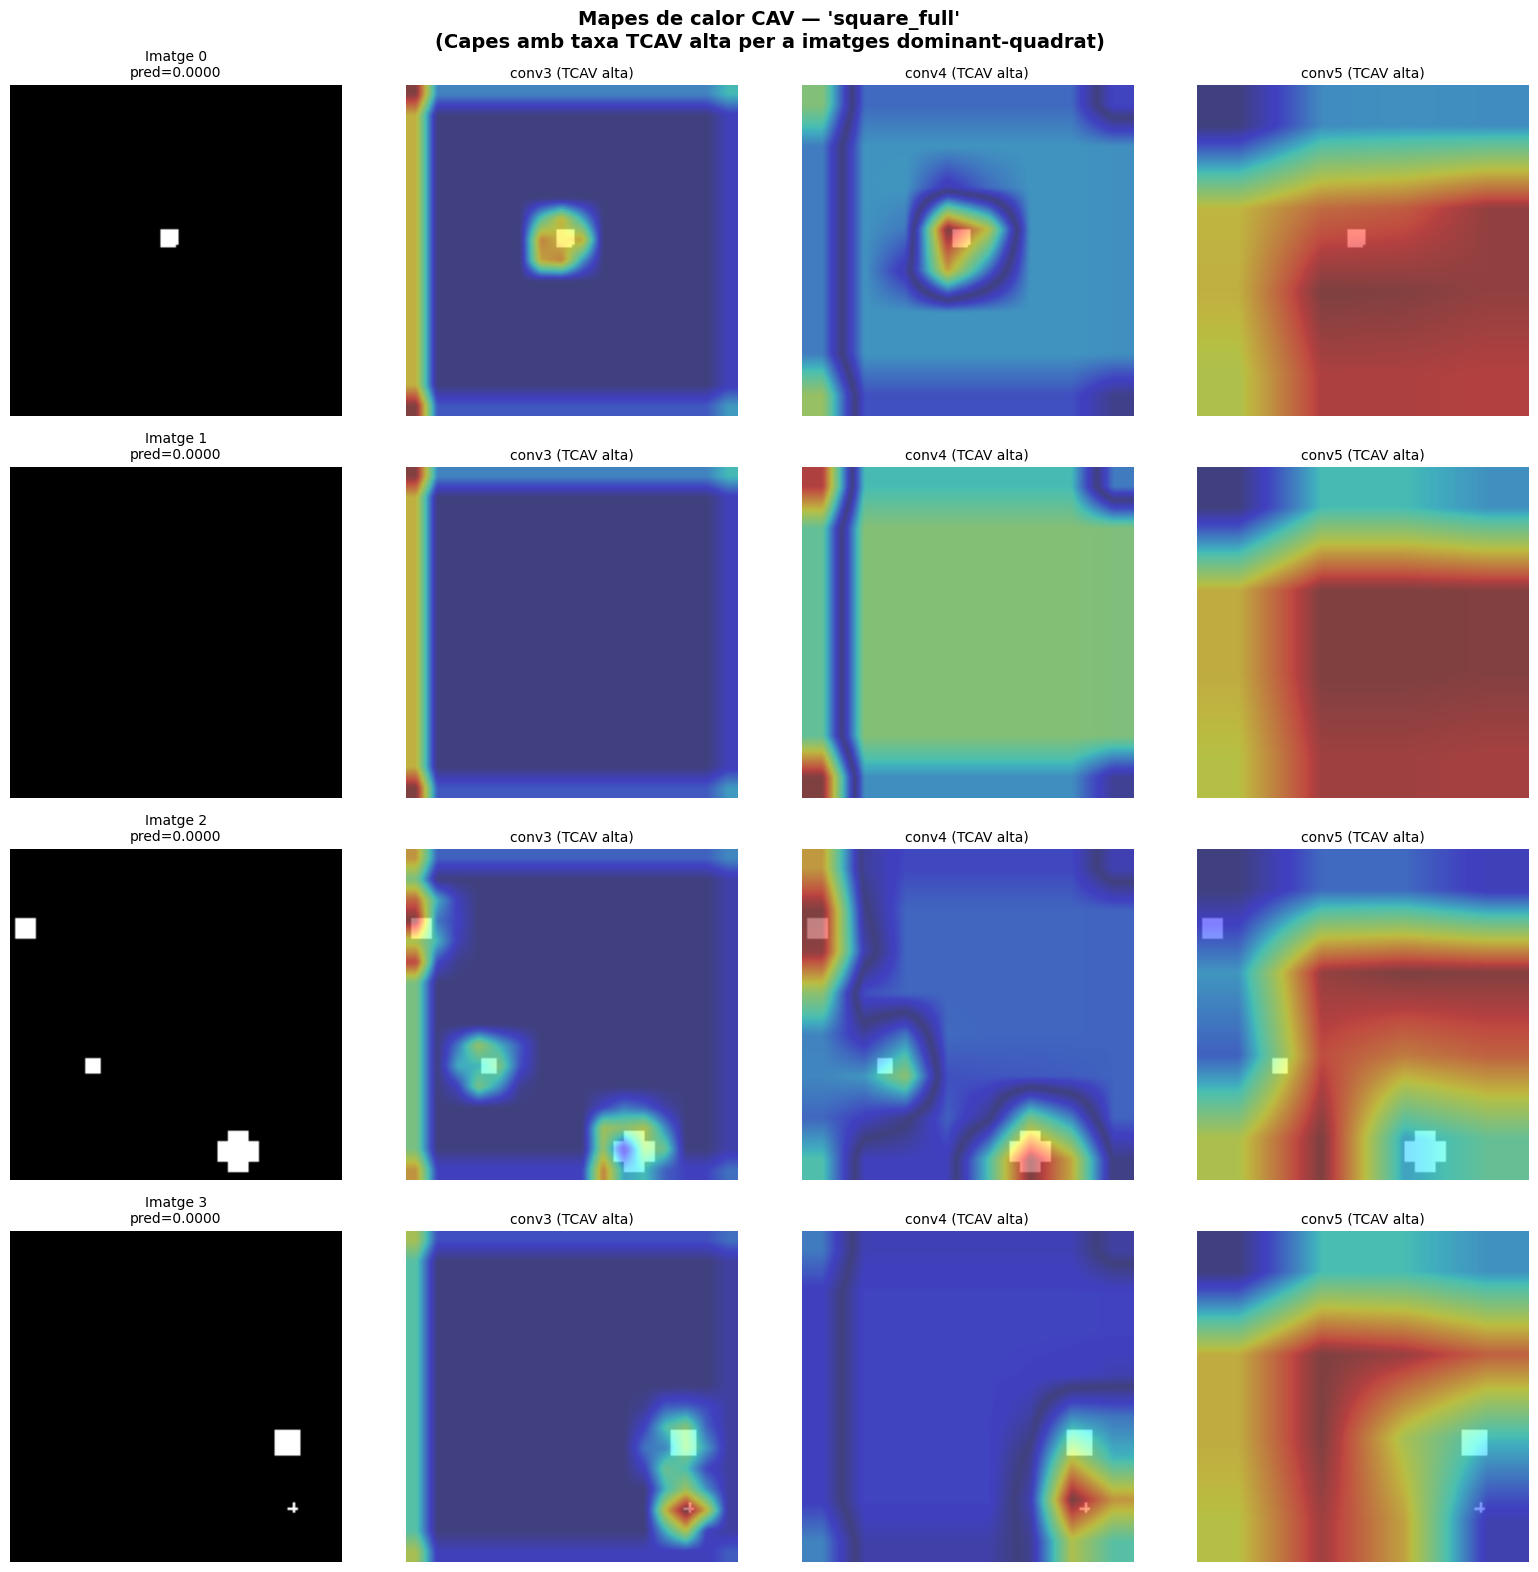

In [17]:
# =============================================
# Mapes de calor per projecció CAV — Imatges dominant-quadrat
# (Capes on la taxa TCAV és alta)
# =============================================
import torch.nn.functional as F

# Parells (concepte, capa) amb taxa TCAV alta (de la secció 11)
high_tcav_pairs = {
    'circle_full':  ['conv3', 'conv4', 'conv5'],
    'cross_full':   ['conv3', 'conv4'],
    'square_full':  ['conv3', 'conv4', 'conv5'],
}

conv_to_maxpool = {
    'conv3': ('maxpool3', 50),
    'conv4': ('maxpool4', 75),
    'conv5': ('maxpool5', 125),
}

N_VIS = 4
vis_images = x_sq_dominant[:N_VIS]

model.eval()
with torch.no_grad():
    vis_preds = model(vis_images).squeeze()

for concept_name, high_layers in high_tcav_pairs.items():
    n_layers = len(high_layers)
    fig, axes = plt.subplots(N_VIS, n_layers + 1, figsize=(4 * (n_layers + 1), 4 * N_VIS))
    fig.suptitle(f"Mapes de calor CAV — '{concept_name}'\n"
                 f"(Capes amb taxa TCAV alta per a imatges dominant-quadrat)", 
                 fontsize=14, fontweight='bold')
    
    for img_idx in range(N_VIS):
        ax = axes[img_idx][0]
        orig = vis_images[img_idx, 0].cpu().numpy()
        ax.imshow(orig, cmap='gray')
        pred_val = vis_preds[img_idx].item() if vis_preds.dim() > 0 else vis_preds.item()
        ax.set_title(f"Imatge {img_idx}\npred={pred_val:.4f}", fontsize=10)
        ax.axis('off')
        
        for col, conv_layer in enumerate(high_layers):
            mp_layer, n_channels = conv_to_maxpool[conv_layer]
            act = activations[mp_layer]
            
            w = cav_weights[concept_name][conv_layer]
            spatial_size = len(w) // n_channels
            w_reshaped = w.reshape(n_channels, spatial_size)
            channel_importance = w_reshaped.mean(axis=1)  # importància signada
            
            act_img = act[img_idx].cpu().numpy()  # [C, H, W]
            heatmap = np.zeros(act_img.shape[1:])
            for c in range(n_channels):
                heatmap += channel_importance[c] * act_img[c]
            
            heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0).float()
            heatmap_upsampled = F.interpolate(heatmap_tensor, size=(128, 128), 
                                               mode='bilinear', align_corners=False)
            hm_abs = np.abs(heatmap_upsampled.squeeze().numpy())
            if hm_abs.max() > 0:
                hm_abs = hm_abs / hm_abs.max()
            
            ax = axes[img_idx][col + 1]
            ax.imshow(orig, cmap='gray', alpha=0.5)
            ax.imshow(hm_abs, cmap='jet', alpha=0.5, interpolation='bilinear')
            ax.set_title(f"{conv_layer} (TCAV alta)", fontsize=10)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    print()

---

## 16. Validació: Projecció CAV en el Règim de Saturació (Imatges de Cercle)

### 16.1 Experiment Clau

**Raonament:** A la Secció 12 hem demostrat que les puntuacions TCAV són zero per a les imatges de cercle a causa de la saturació de la sigmoide. Ara apliquem la **projecció CAV** (que no depèn del gradient) sobre aquestes mateixes imatges per verificar que:

1. Els mapes de calor **sí que són informatius** malgrat la fallada de TCAV.
2. La xarxa efectivament detecta les característiques del concepte "cercle" a les regions espacials corresponents.

### 16.2 Per què funciona?

Recordem les dues components del mapa de calor:

$$\text{heatmap}(h, w) = \sum_{c=1}^{C} \underbrace{\text{importància}(c)}_{\text{pesos CAV}} \cdot \underbrace{A_{c,h,w}}_{\text{activacions}}$$

- **Pesos CAV**: Pre-calculats (no depenen de la imatge d'entrada ni del gradient).
- **Activacions $A_{c,h,w}$**: Generades per la passada endavant, que funciona perfectament independentment de la saturació de la sortida.

**La saturació de la sigmoide afecta el gradient** ($\sigma'(z) \to 0$), **però no les activacions intermèdies**. Per tant, la projecció CAV proporciona un mètode **complementari i més robust** per a la interpretabilitat basada en conceptes.

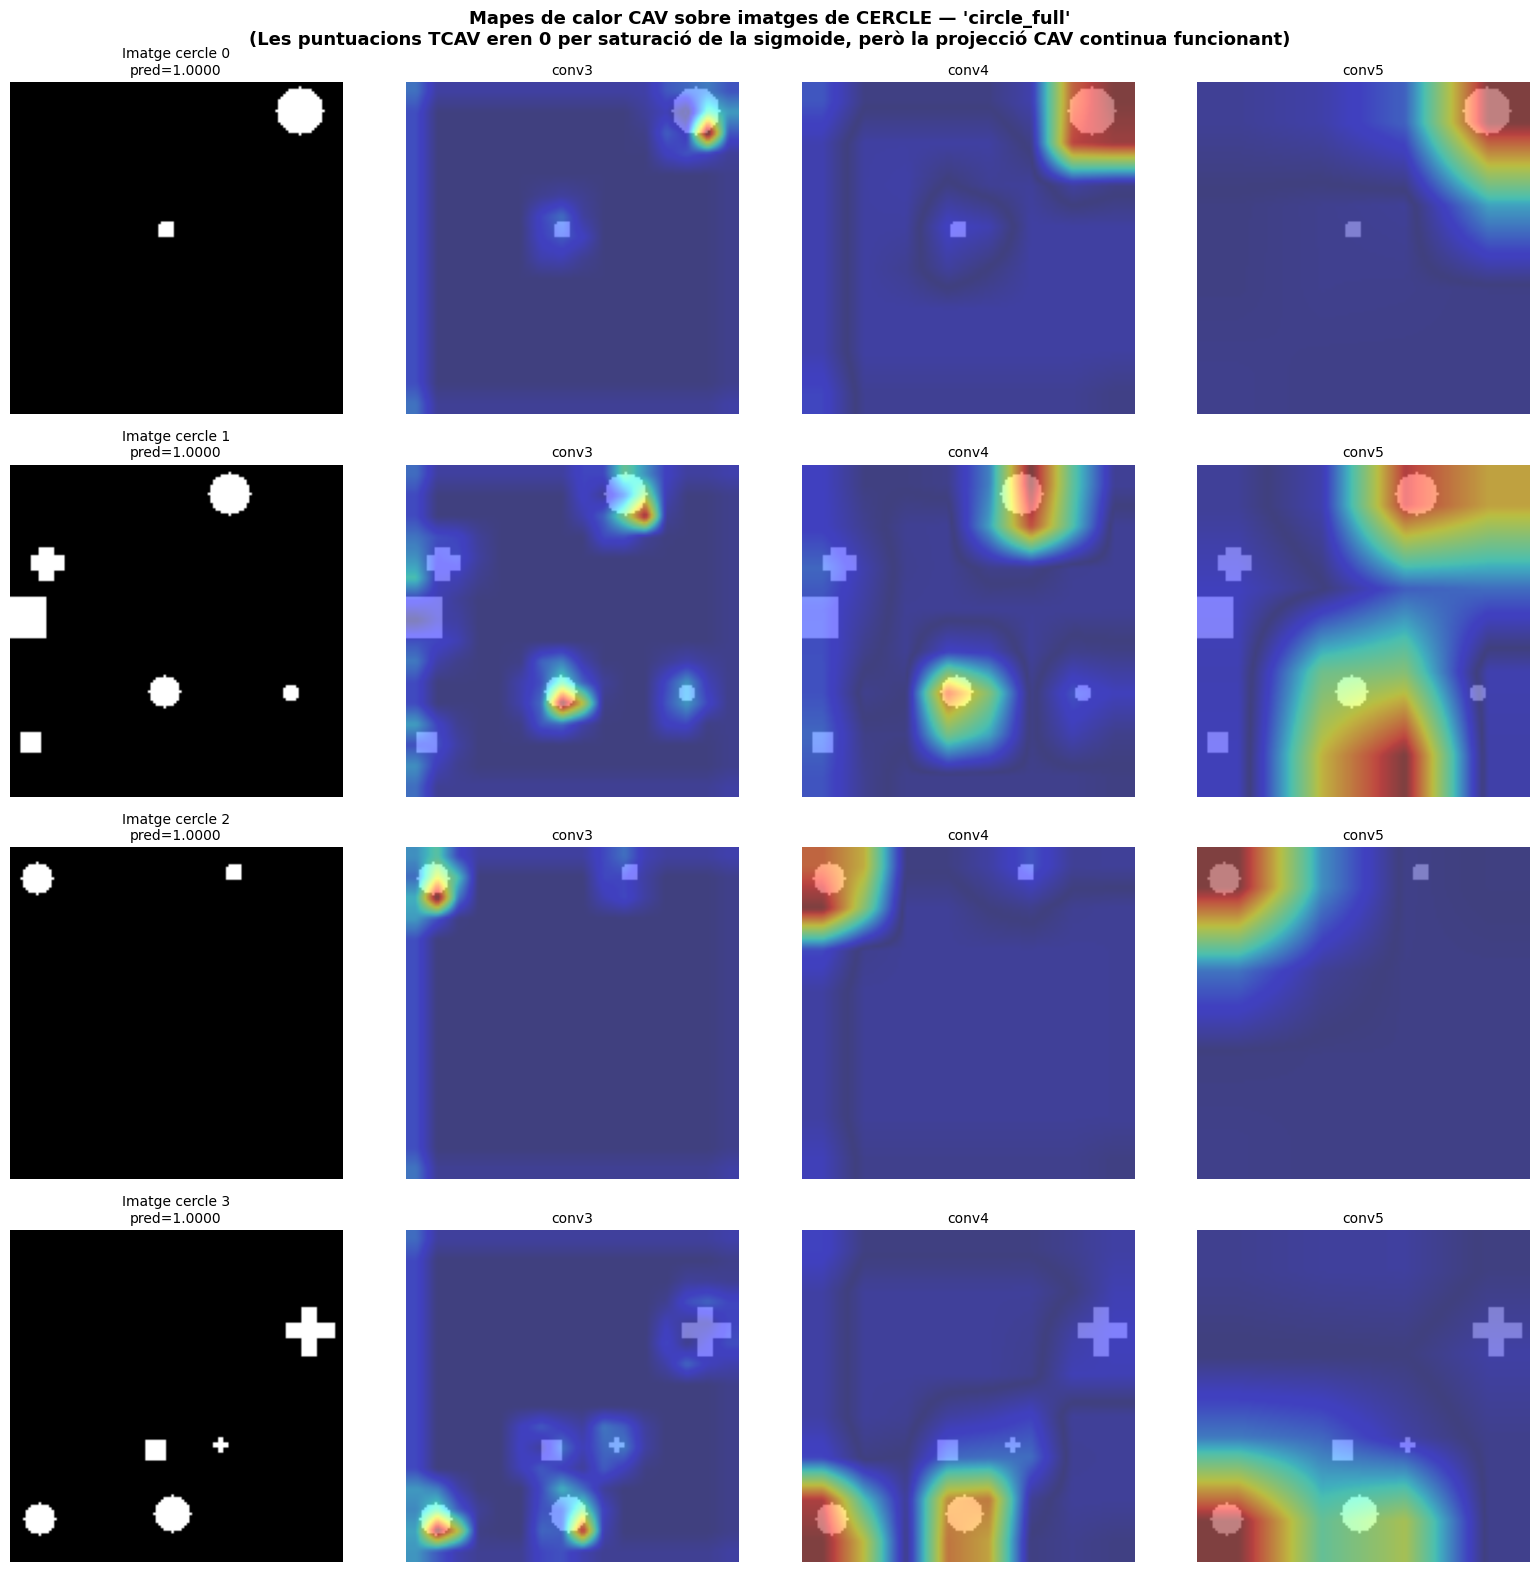

In [18]:
# =============================================
# Mapes de calor CAV sobre imatges de CERCLE
# (On les puntuacions TCAV eren 0 per saturació de la sigmoide)
# =============================================
vis_circle = x_circle[:N_VIS]

with torch.no_grad():
    vis_circle_preds = model(vis_circle).squeeze()

concept_name = 'circle_full'
high_layers = ['conv3', 'conv4', 'conv5']

fig, axes = plt.subplots(N_VIS, len(high_layers) + 1, 
                         figsize=(4 * (len(high_layers) + 1), 4 * N_VIS))
fig.suptitle(
    f"Mapes de calor CAV sobre imatges de CERCLE — '{concept_name}'\n"
    "(Les puntuacions TCAV eren 0 per saturació de la sigmoide, "
    "però la projecció CAV continua funcionant)",
    fontsize=13, fontweight='bold'
)

for img_idx in range(N_VIS):
    ax = axes[img_idx][0]
    orig = vis_circle[img_idx, 0].cpu().numpy()
    ax.imshow(orig, cmap='gray')
    pred_val = vis_circle_preds[img_idx].item() if vis_circle_preds.dim() > 0 else vis_circle_preds.item()
    ax.set_title(f"Imatge cercle {img_idx}\npred={pred_val:.4f}", fontsize=10)
    ax.axis('off')
    
    for col, conv_layer in enumerate(high_layers):
        mp_layer, n_channels = conv_to_maxpool[conv_layer]
        act = activations[mp_layer]
        
        w = cav_weights[concept_name][conv_layer]
        spatial_size = len(w) // n_channels
        w_reshaped = w.reshape(n_channels, spatial_size)
        channel_importance = w_reshaped.mean(axis=1)
        
        act_img = act[img_idx].cpu().numpy()
        heatmap = np.zeros(act_img.shape[1:])
        for c in range(n_channels):
            heatmap += channel_importance[c] * act_img[c]
        
        heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0).float()
        heatmap_upsampled = F.interpolate(heatmap_tensor, size=(128, 128), 
                                           mode='bilinear', align_corners=False)
        hm_abs = np.abs(heatmap_upsampled.squeeze().numpy())
        if hm_abs.max() > 0:
            hm_abs = hm_abs / hm_abs.max()
        
        ax = axes[img_idx][col + 1]
        ax.imshow(orig, cmap='gray', alpha=0.5)
        ax.imshow(hm_abs, cmap='jet', alpha=0.5, interpolation='bilinear')
        ax.set_title(f"{conv_layer}", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

---

## 17. Estudi de Cas: Anàlisi d'una Imatge amb Múltiples Formes

### 17.1 Motivació

**Raonament:** Per completar l'anàlisi, examinem en detall una sola imatge de validació que conté **múltiples formes geomètriques**. Això ens permet:

1. Verificar que els mapes d'activació evolucionen de **detecció de vores fines** (capes primerenques) a **codificació global gruixuda** (capes tardanes).
2. Observar com la "atenció espacial" del model es distribueix entre les diferents formes presents.

### 17.2 Selecció de la Imatge

Seleccionem la imatge d'índex 11 del conjunt de validació, que conté:
- **0 cercles**, **2 quadrats**, **1 creu**
- Etiqueta esperada: $y = 0$ (dominant en quadrats sense cercles)

### 17.3 Visualització

Presentem la imatge original al costat dels 5 mapes d'activació mitjana (maxpool1 a maxpool5), cadascun redimensionat a $128 \times 128$ i superposat sobre la imatge original per il·lustrar l'evolució de l'atenció espacial.

Imatge: data/aixi_shape/val/00011.png
Veritat fonamental: cercles=0, quadrats=2, creus=1
Predicció del model: 0.0000
Etiqueta esperada: 0.0 (dominant-quadrat)
El model diu: dominant-quadrat


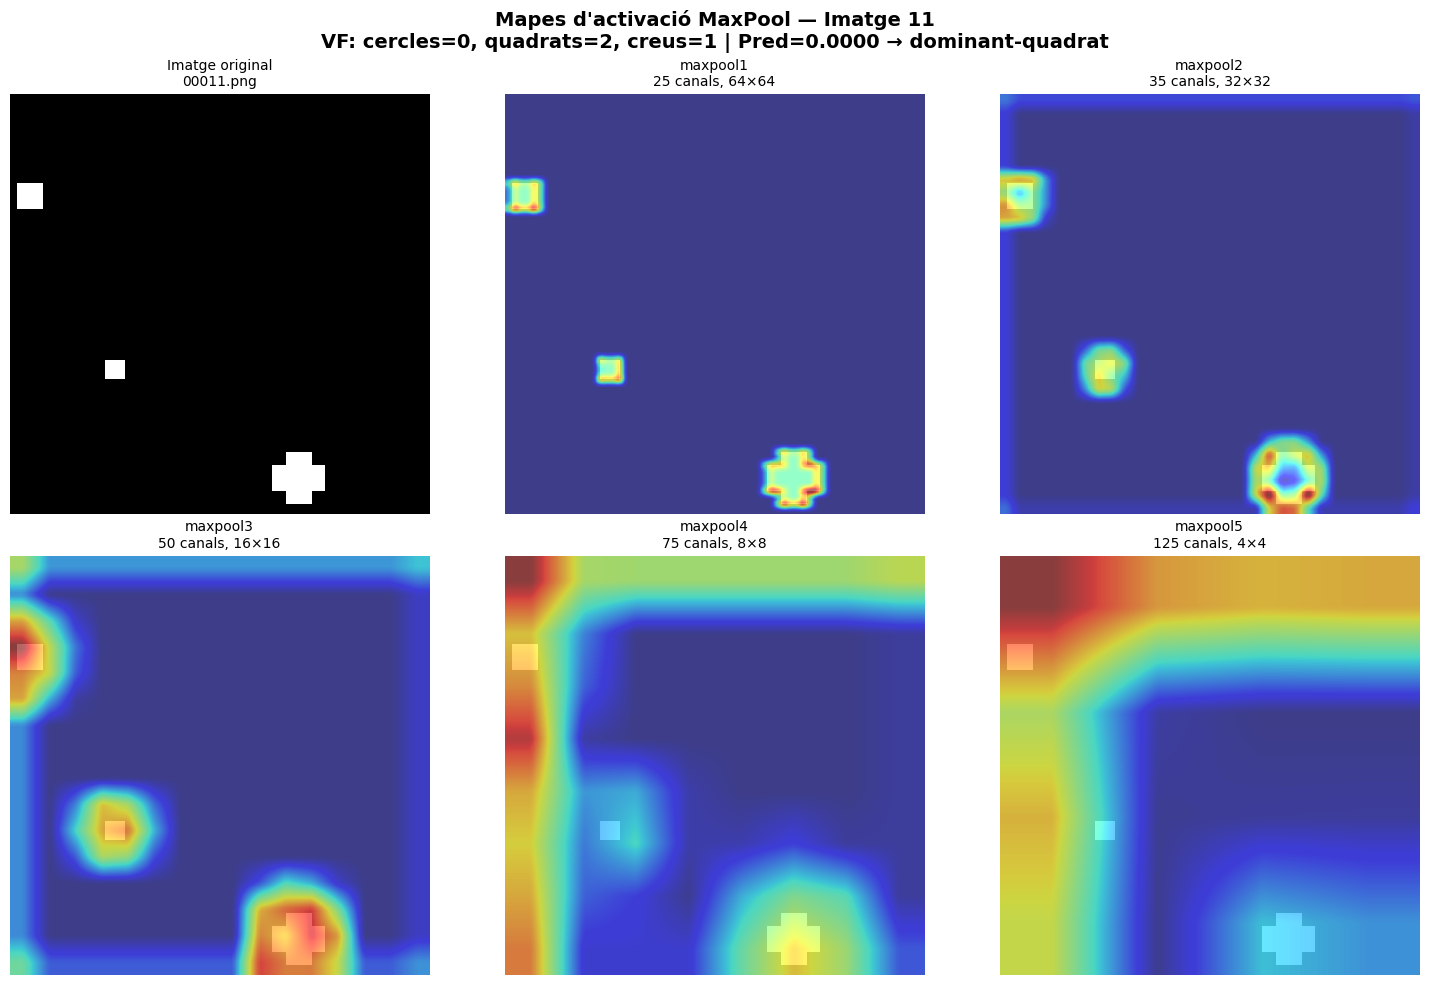

In [19]:
# =============================================
# Anàlisi d'una imatge individual amb múltiples formes
# =============================================
import csv as csv_mod
import torch.nn.functional as F

# Llegir el CSV de validació per obtenir informació de les formes
val_csv_path = "data/aixi_shape/val/dades.csv"
with open(val_csv_path) as f:
    reader = csv_mod.DictReader(f, delimiter=';')
    val_rows = list(reader)

# Imatge índex 11: 0 cercles, 2 quadrats, 1 creu
IMG_IDX = 11
row = val_rows[IMG_IDX]
n_circles, n_squares, n_crosses = int(row['c']), int(row['s']), int(row['cr'])
img_path = f"data/aixi_shape/val/{IMG_IDX:05d}.png"

print(f"Imatge: {img_path}")
print(f"Veritat fonamental: cercles={n_circles}, quadrats={n_squares}, creus={n_crosses}")

img = Image.open(img_path).convert("L")
img_tensor = transform(img).unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    pred = model(img_tensor).item()

expected_label = 0.0 if (n_circles == 0 and n_squares > 0 and n_squares >= n_crosses) else 1.0
print(f"Predicció del model: {pred:.4f}")
print(f"Etiqueta esperada: {expected_label} ({'conté cercles' if expected_label == 1.0 else 'dominant-quadrat'})")
print(f"El model diu: {'conté cercles' if pred > 0.5 else 'dominant-quadrat'}")

# Visualització dels 5 mapes d'activació
maxpool_layers = ['maxpool1', 'maxpool2', 'maxpool3', 'maxpool4', 'maxpool5']
maxpool_info = {
    'maxpool1': (25, '64×64'),
    'maxpool2': (35, '32×32'),
    'maxpool3': (50, '16×16'),
    'maxpool4': (75, '8×8'),
    'maxpool5': (125, '4×4'),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(
    f"Mapes d'activació MaxPool — Imatge {IMG_IDX}\n"
    f"VF: cercles={n_circles}, quadrats={n_squares}, creus={n_crosses} | "
    f"Pred={pred:.4f} → {'conté cercles' if pred > 0.5 else 'dominant-quadrat'}",
    fontsize=14, fontweight='bold'
)

# Imatge original
ax = axes[0][0]
ax.imshow(img_tensor[0, 0].cpu().numpy(), cmap='gray')
ax.set_title(f"Imatge original\n{os.path.basename(img_path)}", fontsize=10)
ax.axis('off')

# 5 capes MaxPool
for i, mp_name in enumerate(maxpool_layers):
    row_idx = (i + 1) // 3
    col_idx = (i + 1) % 3
    ax = axes[row_idx][col_idx]
    
    act = activations[mp_name]
    n_ch, spatial = maxpool_info[mp_name]
    mean_act = act[0].mean(dim=0).cpu().numpy()
    
    mean_tensor = torch.tensor(mean_act).unsqueeze(0).unsqueeze(0).float()
    mean_up = F.interpolate(mean_tensor, size=(128, 128), 
                            mode='bilinear', align_corners=False).squeeze().numpy()
    if mean_up.max() > 0:
        mean_up = mean_up / mean_up.max()
    
    ax.imshow(img_tensor[0, 0].cpu().numpy(), cmap='gray', alpha=0.4)
    ax.imshow(mean_up, cmap='jet', alpha=0.6, interpolation='bilinear')
    ax.set_title(f"{mp_name}\n{n_ch} canals, {spatial}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

---

## 18. Conclusions

### 18.1 Resum de Troballes

1. **La magnitud dels pesos CAV augmenta amb la profunditat de la capa:** Les capes convolucionals codifiquen els conceptes en representacions distribuïdes d'alta dimensionalitat amb pesos individuals petits. Les capes fully connected comprimeixen aquesta informació en representacions disperses d'alta magnitud, amb `fc2` mostrant la discriminabilitat de concepte més forta.

2. **Les puntuacions TCAV fallen sota saturació de la sigmoide:** Quan la sigmoide de sortida del model està saturada ($\hat{y} \approx 0$ o $\hat{y} \approx 1$), el gradient evanescent anul·la totes les puntuacions TCAV. Aquesta és una **limitació fonamental** del TCAV basat en gradient per a models amb sortida sigmoide.

3. **Les projeccions espacials CAV són lliures de gradient:** Projectant els pesos CAV directament sobre els mapes d'activació (sense calcular gradients de la sortida), la localització de conceptes roman funcional fins i tot en el règim de saturació. Això proporciona un mètode **complementari i més robust** per a la interpretabilitat espacial basada en conceptes.

4. **La codificació de conceptes depèn de la capa:** Les taxes TCAV són altes a les capes convolucionals intermèdies-tardanes (conv3–conv5) però cauen a zero a les capes FC, suggerint que la sensibilitat basada en gradient als conceptes geomètrics es localitza en les etapes d'extracció de característiques espacials.

### 18.2 Implicacions Metodològiques

- **Per a models amb sigmoide:** La projecció CAV (Secció 15) hauria de complementar sempre les puntuacions TCAV estàndard.
- **Selecció de capes:** Les capes convolucionals tardanes (`conv4`, `conv5`) semblen el millor compromís entre informació espacial i codificació de conceptes.
- **Alternativa per a sortides saturades:** Considerar l'ús del logit pre-sigmoide com a objectiu de TCAV en comptes de la sortida post-sigmoide.

### 18.3 Referències

- **TCAV:** Kim, B., Wattenberg, M., Gilmer, J., Cai, C., Wexler, J., Viegas, F., & Sayres, R. (2018). *Interpretability Beyond Feature Attribution: Quantitative Testing with Concept Activation Vectors (TCAV)*. ICML 2018.
- **Captum:** Kokhlikyan, N. et al. (2020). *Captum: A unified and generic model interpretability library for PyTorch*.
- **Projecció espacial CAV:** El mètode de mapes de calor de les Seccions 15-16 estén el TCAV estàndard utilitzant els pesos del classificador lineal com a operador de projecció sobre mapes d'activació resolts espacialment, permetent la localització de conceptes sense computació de gradients.